In [1]:
# Injection and Recovery

In [2]:
# run the import and install packages.py file 
%run install_packages.py

MIRSI Simulations - Package Dependency Checker

Checking for required packages...
✓ numpy is already installed
✓ astropy is already installed
✓ matplotlib is already installed
✓ photutils is already installed
✓ scipy is already installed

✓ All required packages are already installed!

Setup complete! You can now run the MIRSI simulations.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry, RectangularAperture
# Read in the data from the fits file 
from test_analysis import read_in_fits
from analysis_functions import *

In [4]:
TRIM_FRAMES = (199, -1)

In [5]:
zenith_sky_1_data = read_in_fits('./data/260203/zenith_sky_1')

Processing 1500 FITS files from ./data/260203/zenith_sky_1
Loaded 1500 FITS files from ./data/260203/zenith_sky_1


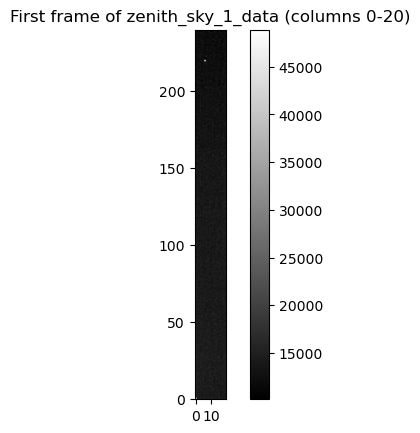

In [6]:
# Pick the first image and just preview columns 0 - 20 and all rows to see what a channel looks like
plt.imshow(zenith_sky_1_data[0, :, :20], cmap='gray', origin='lower')
plt.title("First frame of zenith_sky_1_data (columns 0-20)")
plt.colorbar()
plt.show()

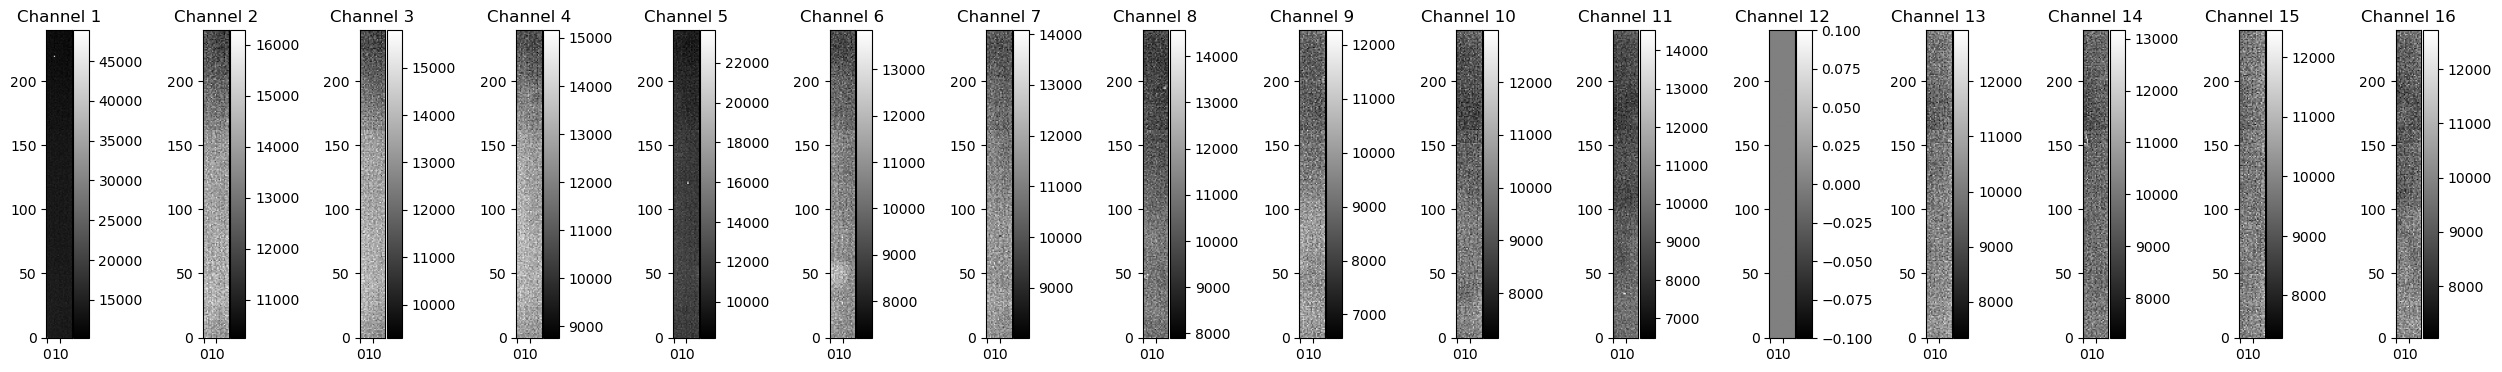

In [7]:
num_channels = 16
channel_data = []

fig, axes = plt.subplots(1, num_channels, figsize=(32, 4))

for i in range(num_channels):
    channel_data.append(zenith_sky_1_data[:, :, i*20:(i+1)*20])
    im = axes[i].imshow(channel_data[i][0], cmap='gray', origin='lower')
    axes[i].set_title("Channel {}".format(i+1))
    plt.colorbar(im, ax=axes[i], pad =0.01)

plt.show()

## Compute $R(f_c)$

## First define an aperture andf compute the measured variance $\sigma^2(f_c)$ within it

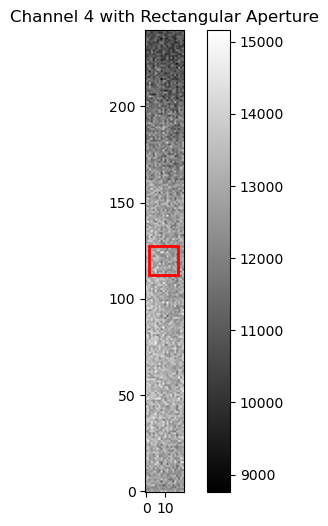

In [8]:
# Take the 4th channel and define a rectangular aperture of radius of size 8 x 8 pixels centered on the middle of the image (no annulus for background subtraction)
channel_4_data = channel_data[3]
aperture = RectangularAperture((9,120), 15, 15) 
# display aperture 
fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(channel_4_data[0], cmap='gray', origin='lower')
aperture.plot(color='red', lw=2, ax=ax)
ax.set_title("Channel 4 with Rectangular Aperture")
plt.colorbar(im, ax=ax)
plt.show()  


The 

In [9]:
np.shape(zenith_sky_1_data)

(1500, 240, 320)

In [10]:
# Build channels as bef|ore
result = extract_channels(zenith_sky_1_data, channel_width=20, trim=TRIM_FRAMES)

In [11]:
np.shape(result["channels"])

(16, 1300, 240, 20)

In [12]:
coadds = np.arange(5,300)

In [13]:
# Aperture in channel-local coordinates (x in [0, 19], y in [0, ny-1])
ap = RectangularAperture((9, 120), 15, 15)

variances, t_dwell, f_state, f_coadd = create_variance_curve(result["channels"], coadds_array=coadds, frame_dt_s=0.0103, aperture=ap)


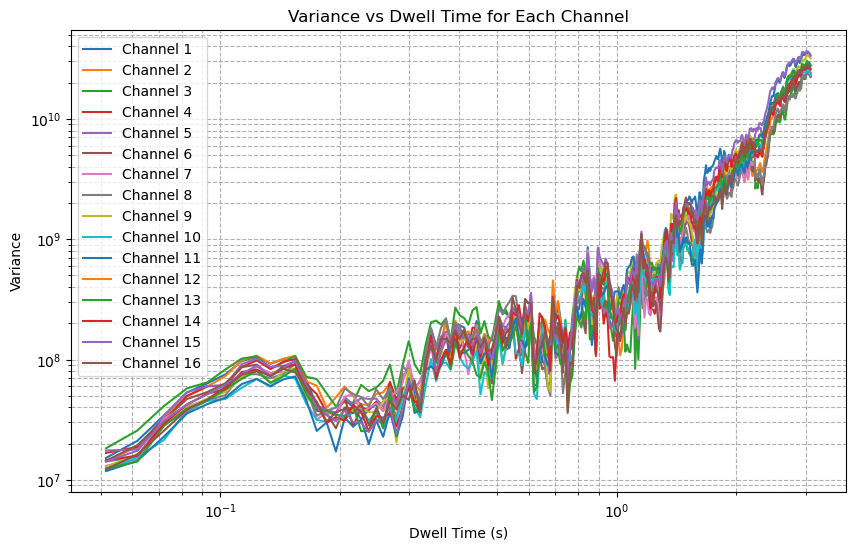

In [14]:
# Plot by dwell time instead 
plt.figure(figsize=(10, 6))
for channel in range(result["channels"].shape[0]):
    channel_variance = [variances[n][channel] for n in coadds]
    plt.plot(t_dwell, channel_variance, label=f'Channel {channel+1}')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Dwell Time (s)')
plt.ylabel('Variance')
plt.title('Variance vs Dwell Time for Each Channel')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

/tmp/ipykernel_2192382/3261808668.py:12: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale('log')


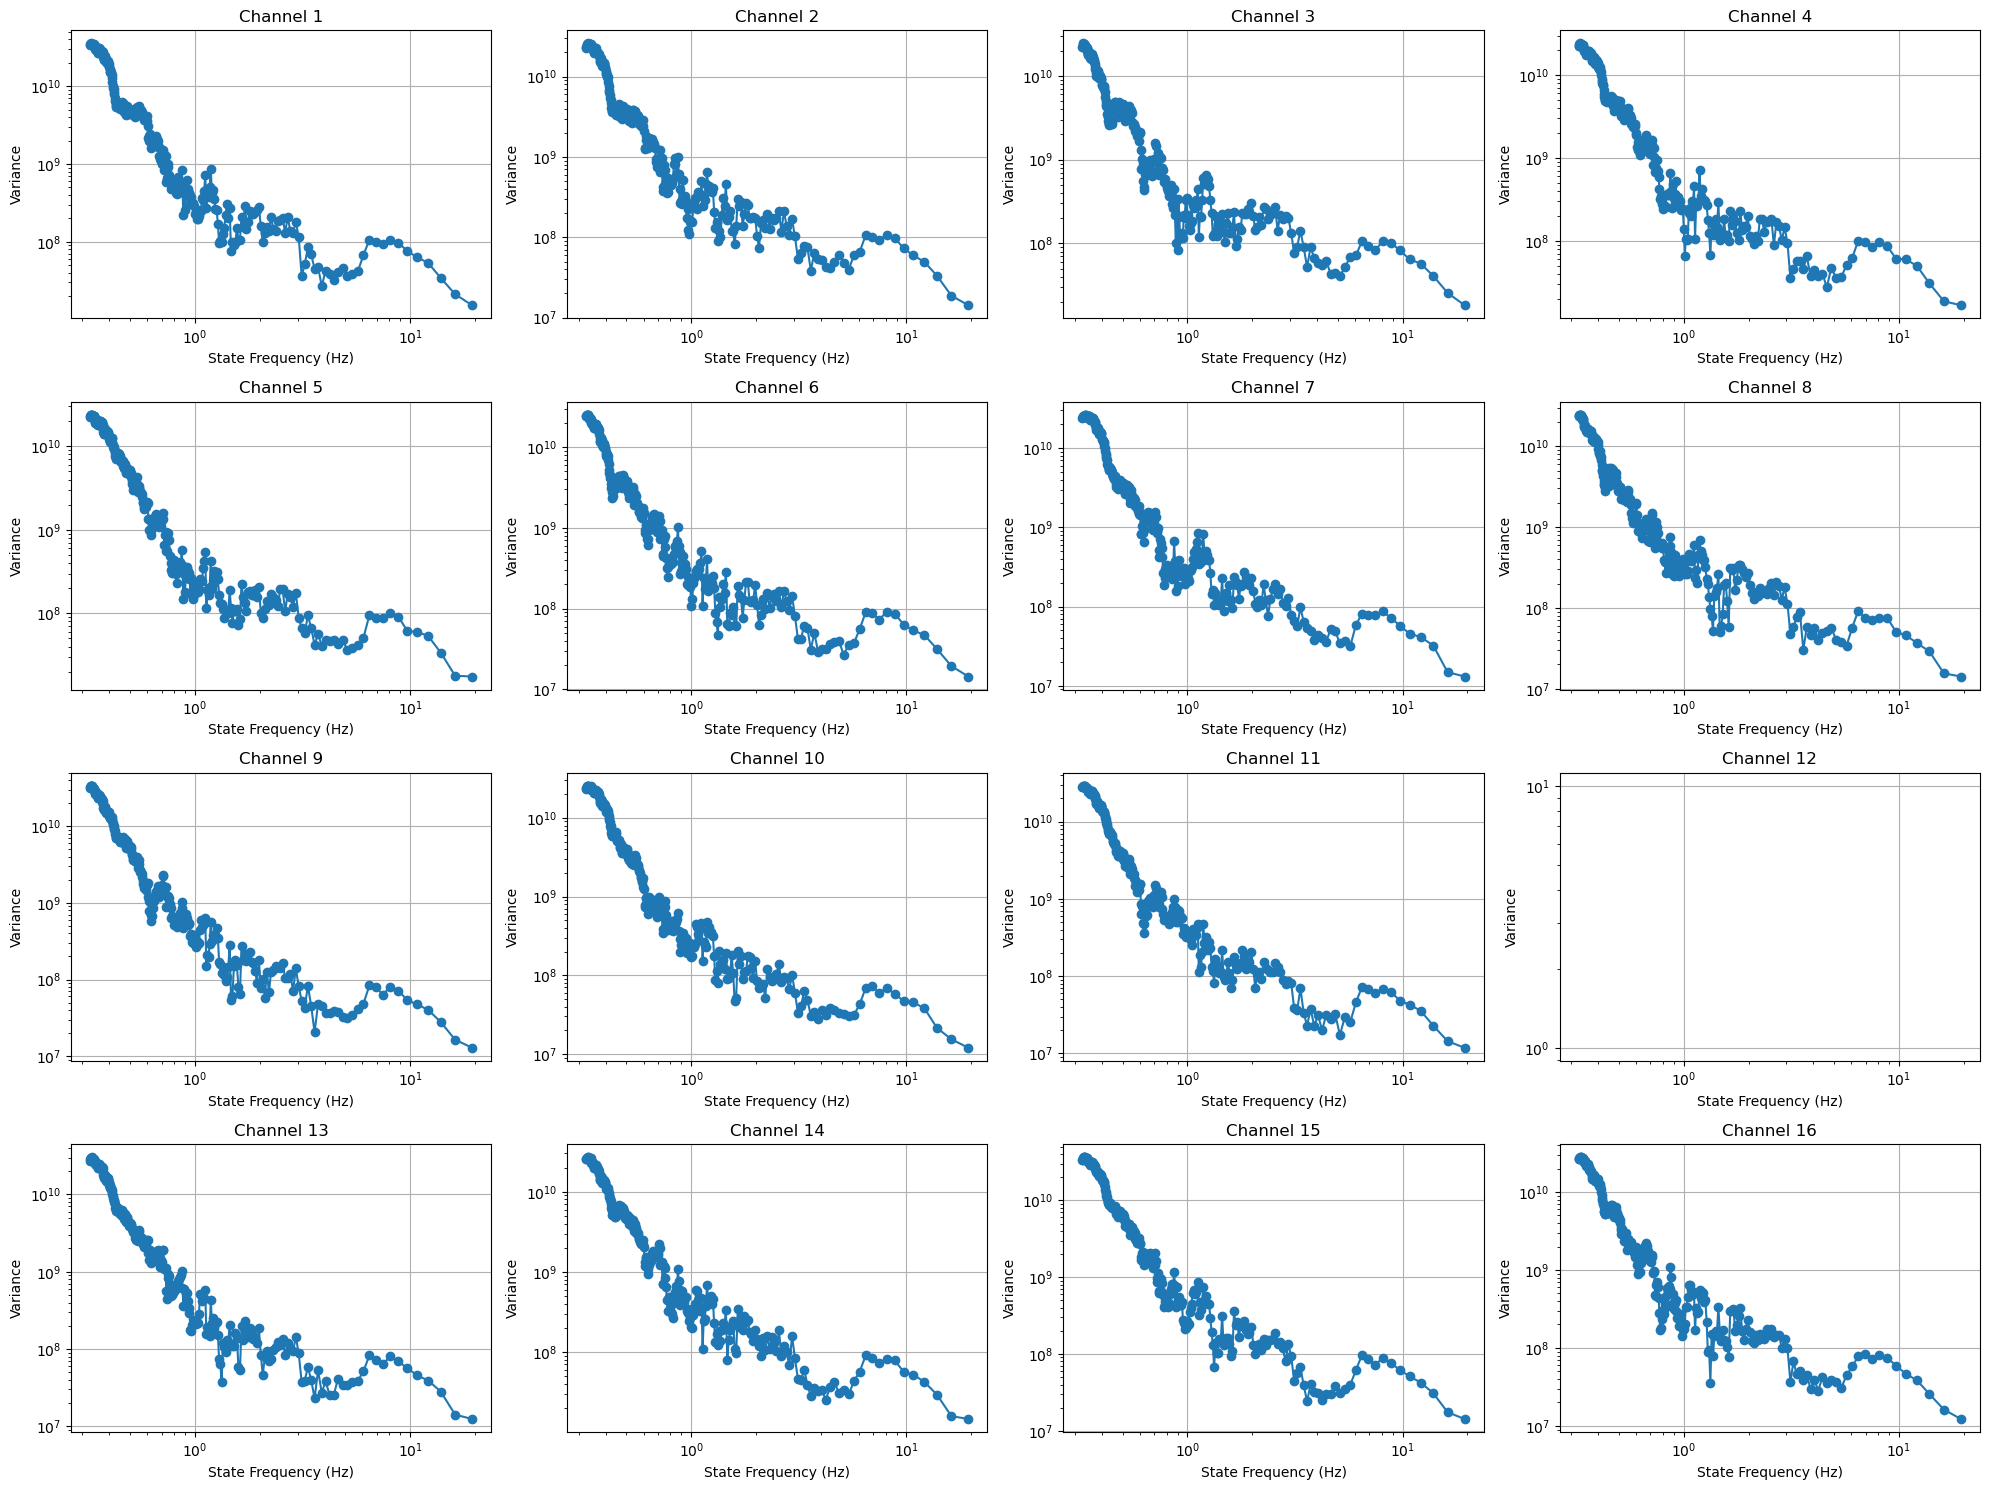

In [15]:
# Loop over all channels and plot the variance curves
fig, axes = plt.subplots(4, 4, figsize=(20, 15))
for channel in range(result["channels"].shape[0]):
    ax = axes[channel // 4, channel % 4]
    ch_variance = [variances[n][channel] for n in coadds]
    ax.plot(f_state, ch_variance, marker='o')
    ax.set_title(f'Channel {channel+1}')
    ax.set_xlabel('State Frequency (Hz)')
    ax.set_ylabel('Variance')
    ax.grid( True )
    ax.set_xscale('log')
    ax.set_yscale('log')
plt.tight_layout()
plt.show()


Great, now set the curve for the fiducial frequency term (say 0.5 Hz)

In [16]:
f_OS = 0.8 # Hz 

# Compute the variance of the sky at at that frequency for each channel
sky_variances_at_f_OS = []
for channel in range(result["channels"].shape[0]):
    ch_variance = [variances[n][channel] for n in coadds]
    # Interpolate to find the variance at f_OS
    variance_at_f_OS = np.interp(f_OS, f_state[::-1], ch_variance)
    sky_variances_at_f_OS.append(variance_at_f_OS)

In [17]:
# Cell: variance at f_OS
f_OS = 0.5  # Hz
sky_variances_at_f_OS = []

for channel in range(result["channels"].shape[0]):
    ch_variance = np.array([variances[n][channel] for n in coadds], dtype=float)

    # Keep x-y pairing consistent: both reversed
    variance_at_f_OS = np.interp(f_OS, np.array(f_state)[::-1], ch_variance[::-1])
    sky_variances_at_f_OS.append(variance_at_f_OS)

sky_variances_at_f_OS = np.array(sky_variances_at_f_OS, dtype=float)

/tmp/ipykernel_2192382/2017581267.py:13: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale('log')


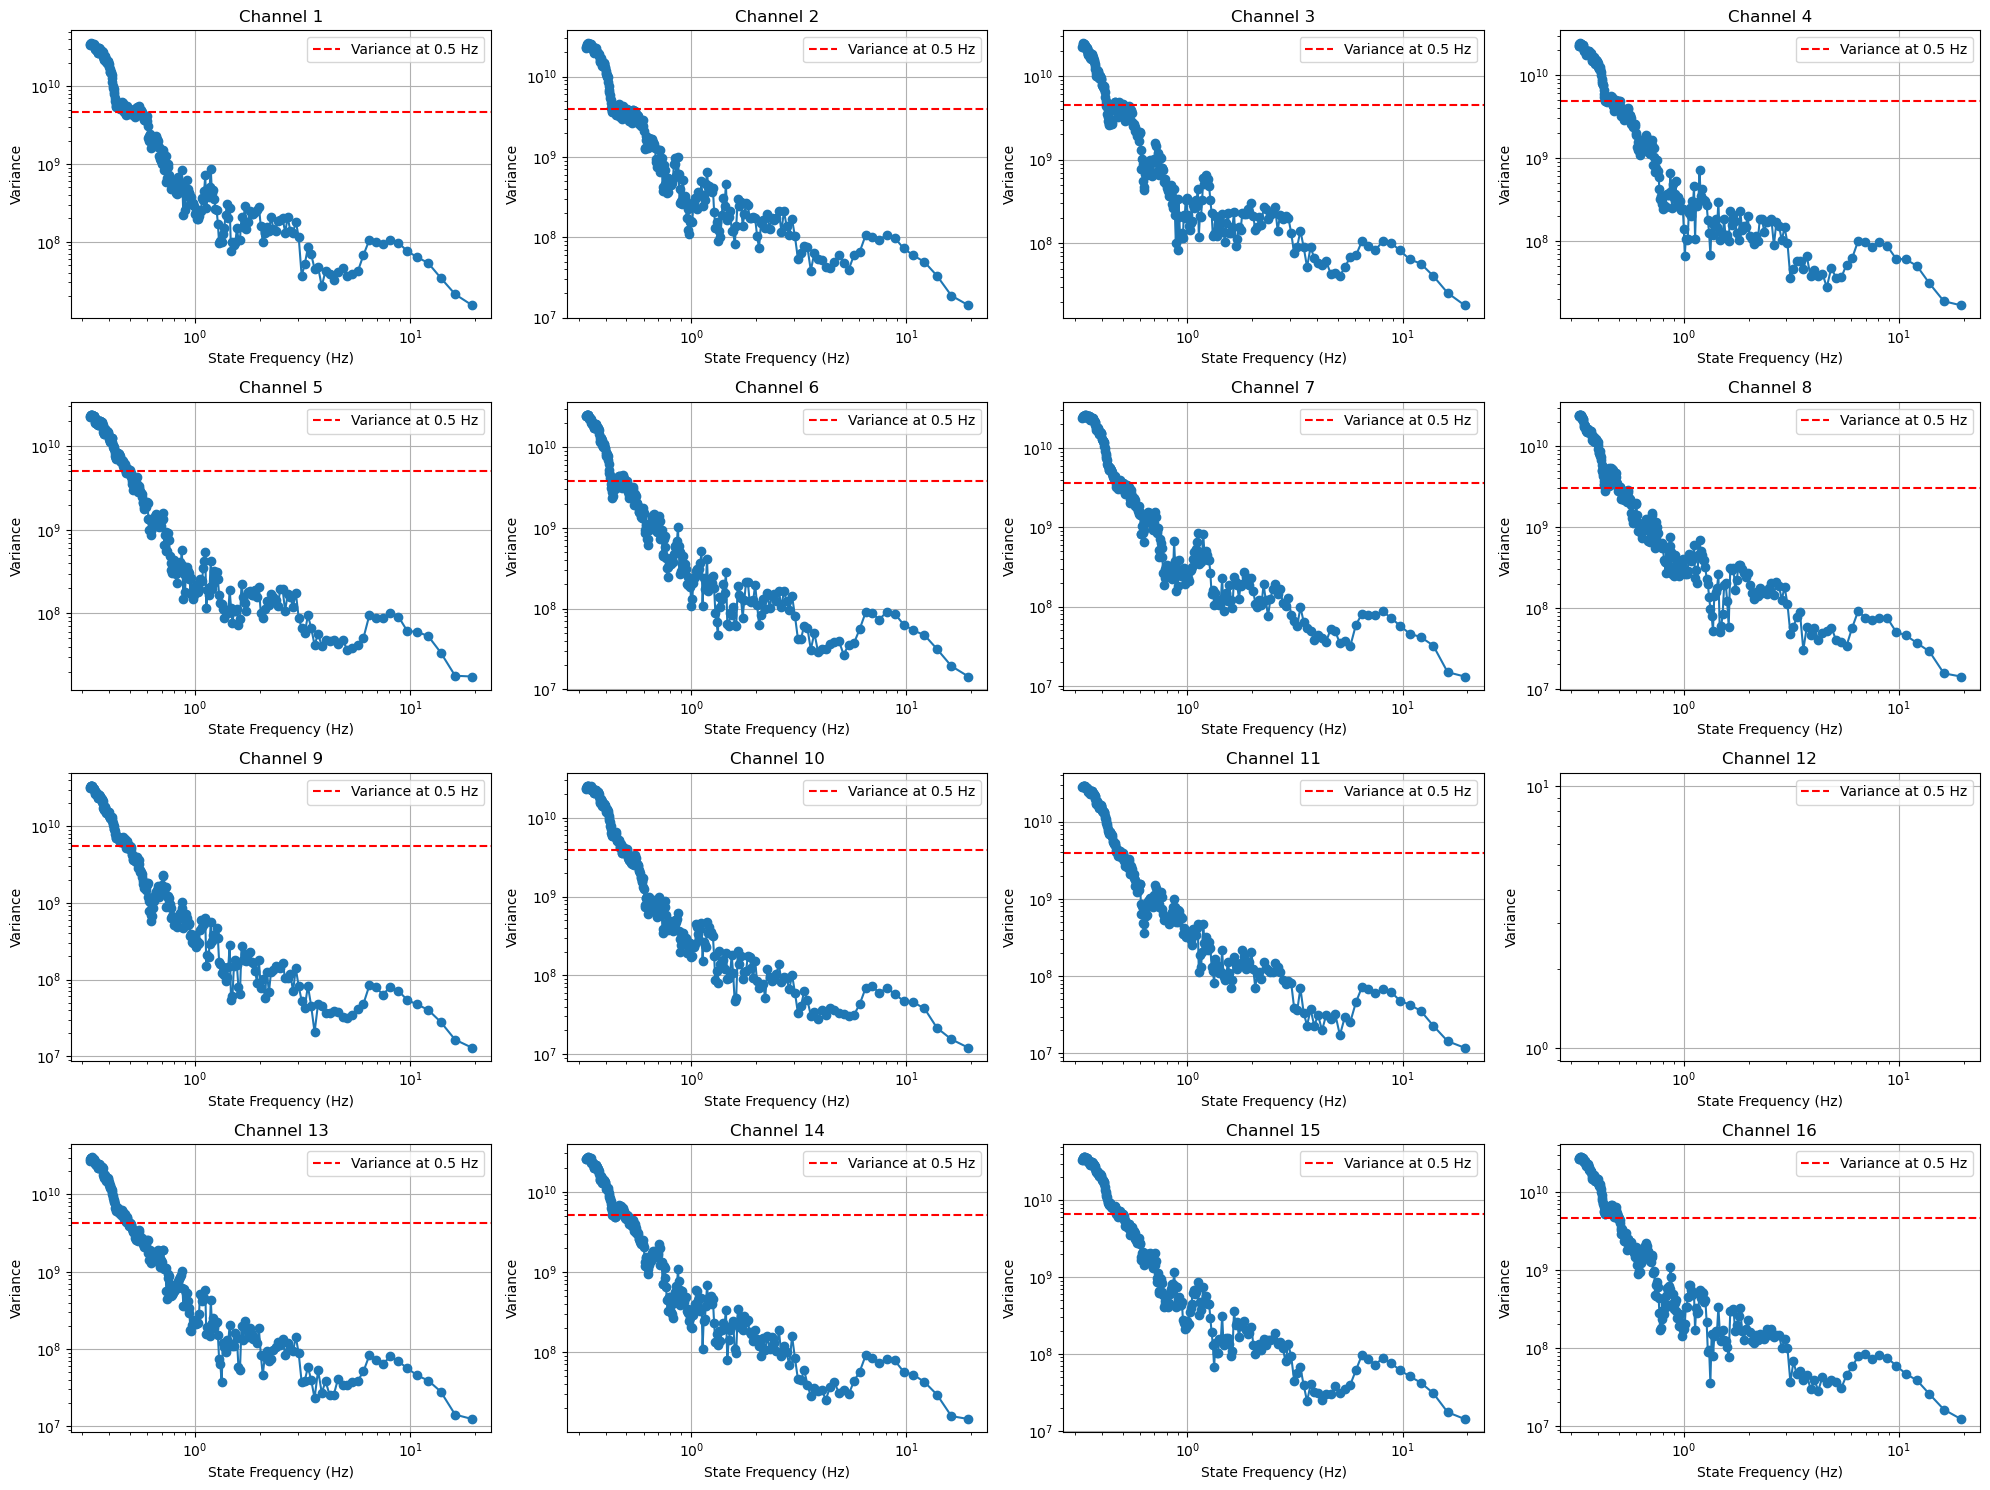

In [18]:
# For each channel, plot the variace curve and mark the variance at f_OS
fig, axes = plt.subplots(4, 4, figsize=(20, 15))
for channel in range(result["channels"].shape[0]):
    ax = axes[channel // 4, channel % 4]
    ch_variance = [variances[n][channel] for n in coadds]
    ax.plot(f_state, ch_variance, marker='o')
    ax.axhline(sky_variances_at_f_OS[channel], color='red', linestyle='--', label=f'Variance at {f_OS} Hz')
    ax.set_title(f'Channel {channel+1}')
    ax.set_xlabel('State Frequency (Hz)')
    ax.set_ylabel('Variance')
    ax.grid( True )
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.legend()
plt.tight_layout()
plt.show()

In [19]:
# at each channel, divide the variance by the variance at f_OS to get a normalized variance curve
# Initialize array with with shape (num_channels, state_frequencies)
# Cell: R_factor
ch_var_matrix = np.array([[variances[n][ch] for n in coadds]
                          for ch in range(result["channels"].shape[0])], dtype=float)

# Safe divide; invalid denominators become NaN
den = sky_variances_at_f_OS[:, None]
R_factor = np.divide(
    ch_var_matrix, den,
    out=np.full_like(ch_var_matrix, np.nan),
    where=np.isfinite(den) & (den > 0)
)

In [20]:
np.shape(R_factor)

(16, 295)

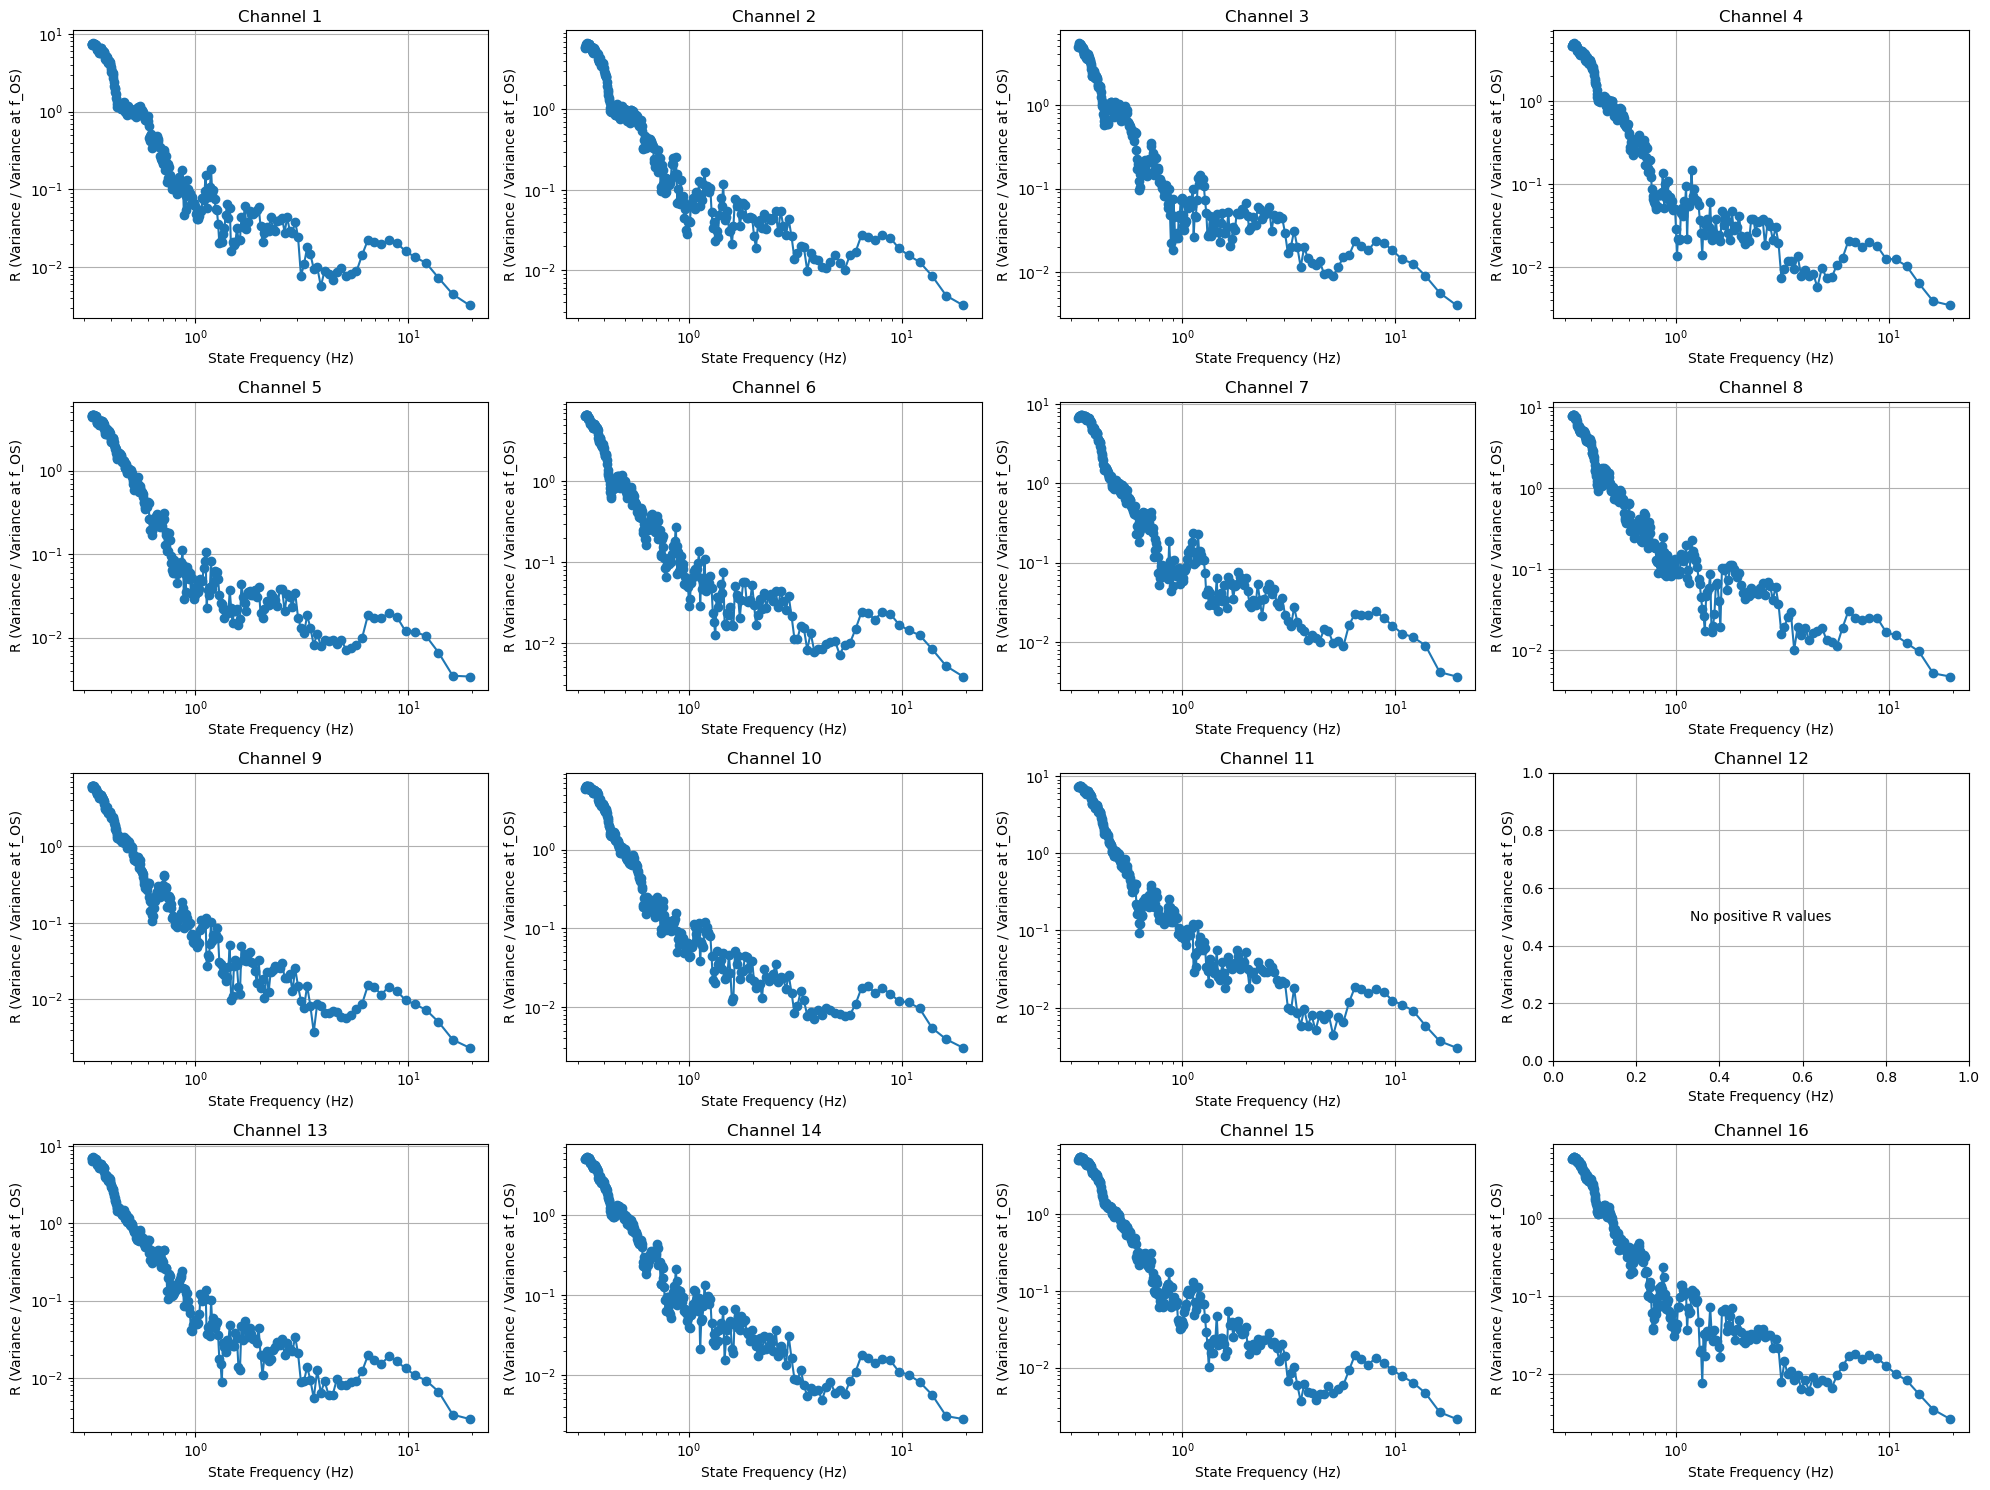

In [21]:
# Cell: Plot R
fig, axes = plt.subplots(4, 4, figsize=(20, 15))
for channel in range(result["channels"].shape[0]):
    ax = axes[channel // 4, channel % 4]
    R_values = np.array(R_factor[channel], dtype=float)
    xvals = np.array(f_state, dtype=float)

    # Log scale requires strictly positive finite values
    good = np.isfinite(R_values) & (R_values > 0) & np.isfinite(xvals) & (xvals > 0)

    if np.any(good):
        ax.plot(xvals[good], R_values[good], marker='o')
        ax.set_xscale('log')
        ax.set_yscale('log')
    else:
        ax.text(0.5, 0.5, "No positive R values", ha='center', va='center', transform=ax.transAxes)

    ax.set_title(f'Channel {channel+1}')
    ax.set_xlabel('State Frequency (Hz)')
    ax.set_ylabel('R (Variance / Variance at f_OS)')
    ax.grid(True)


plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


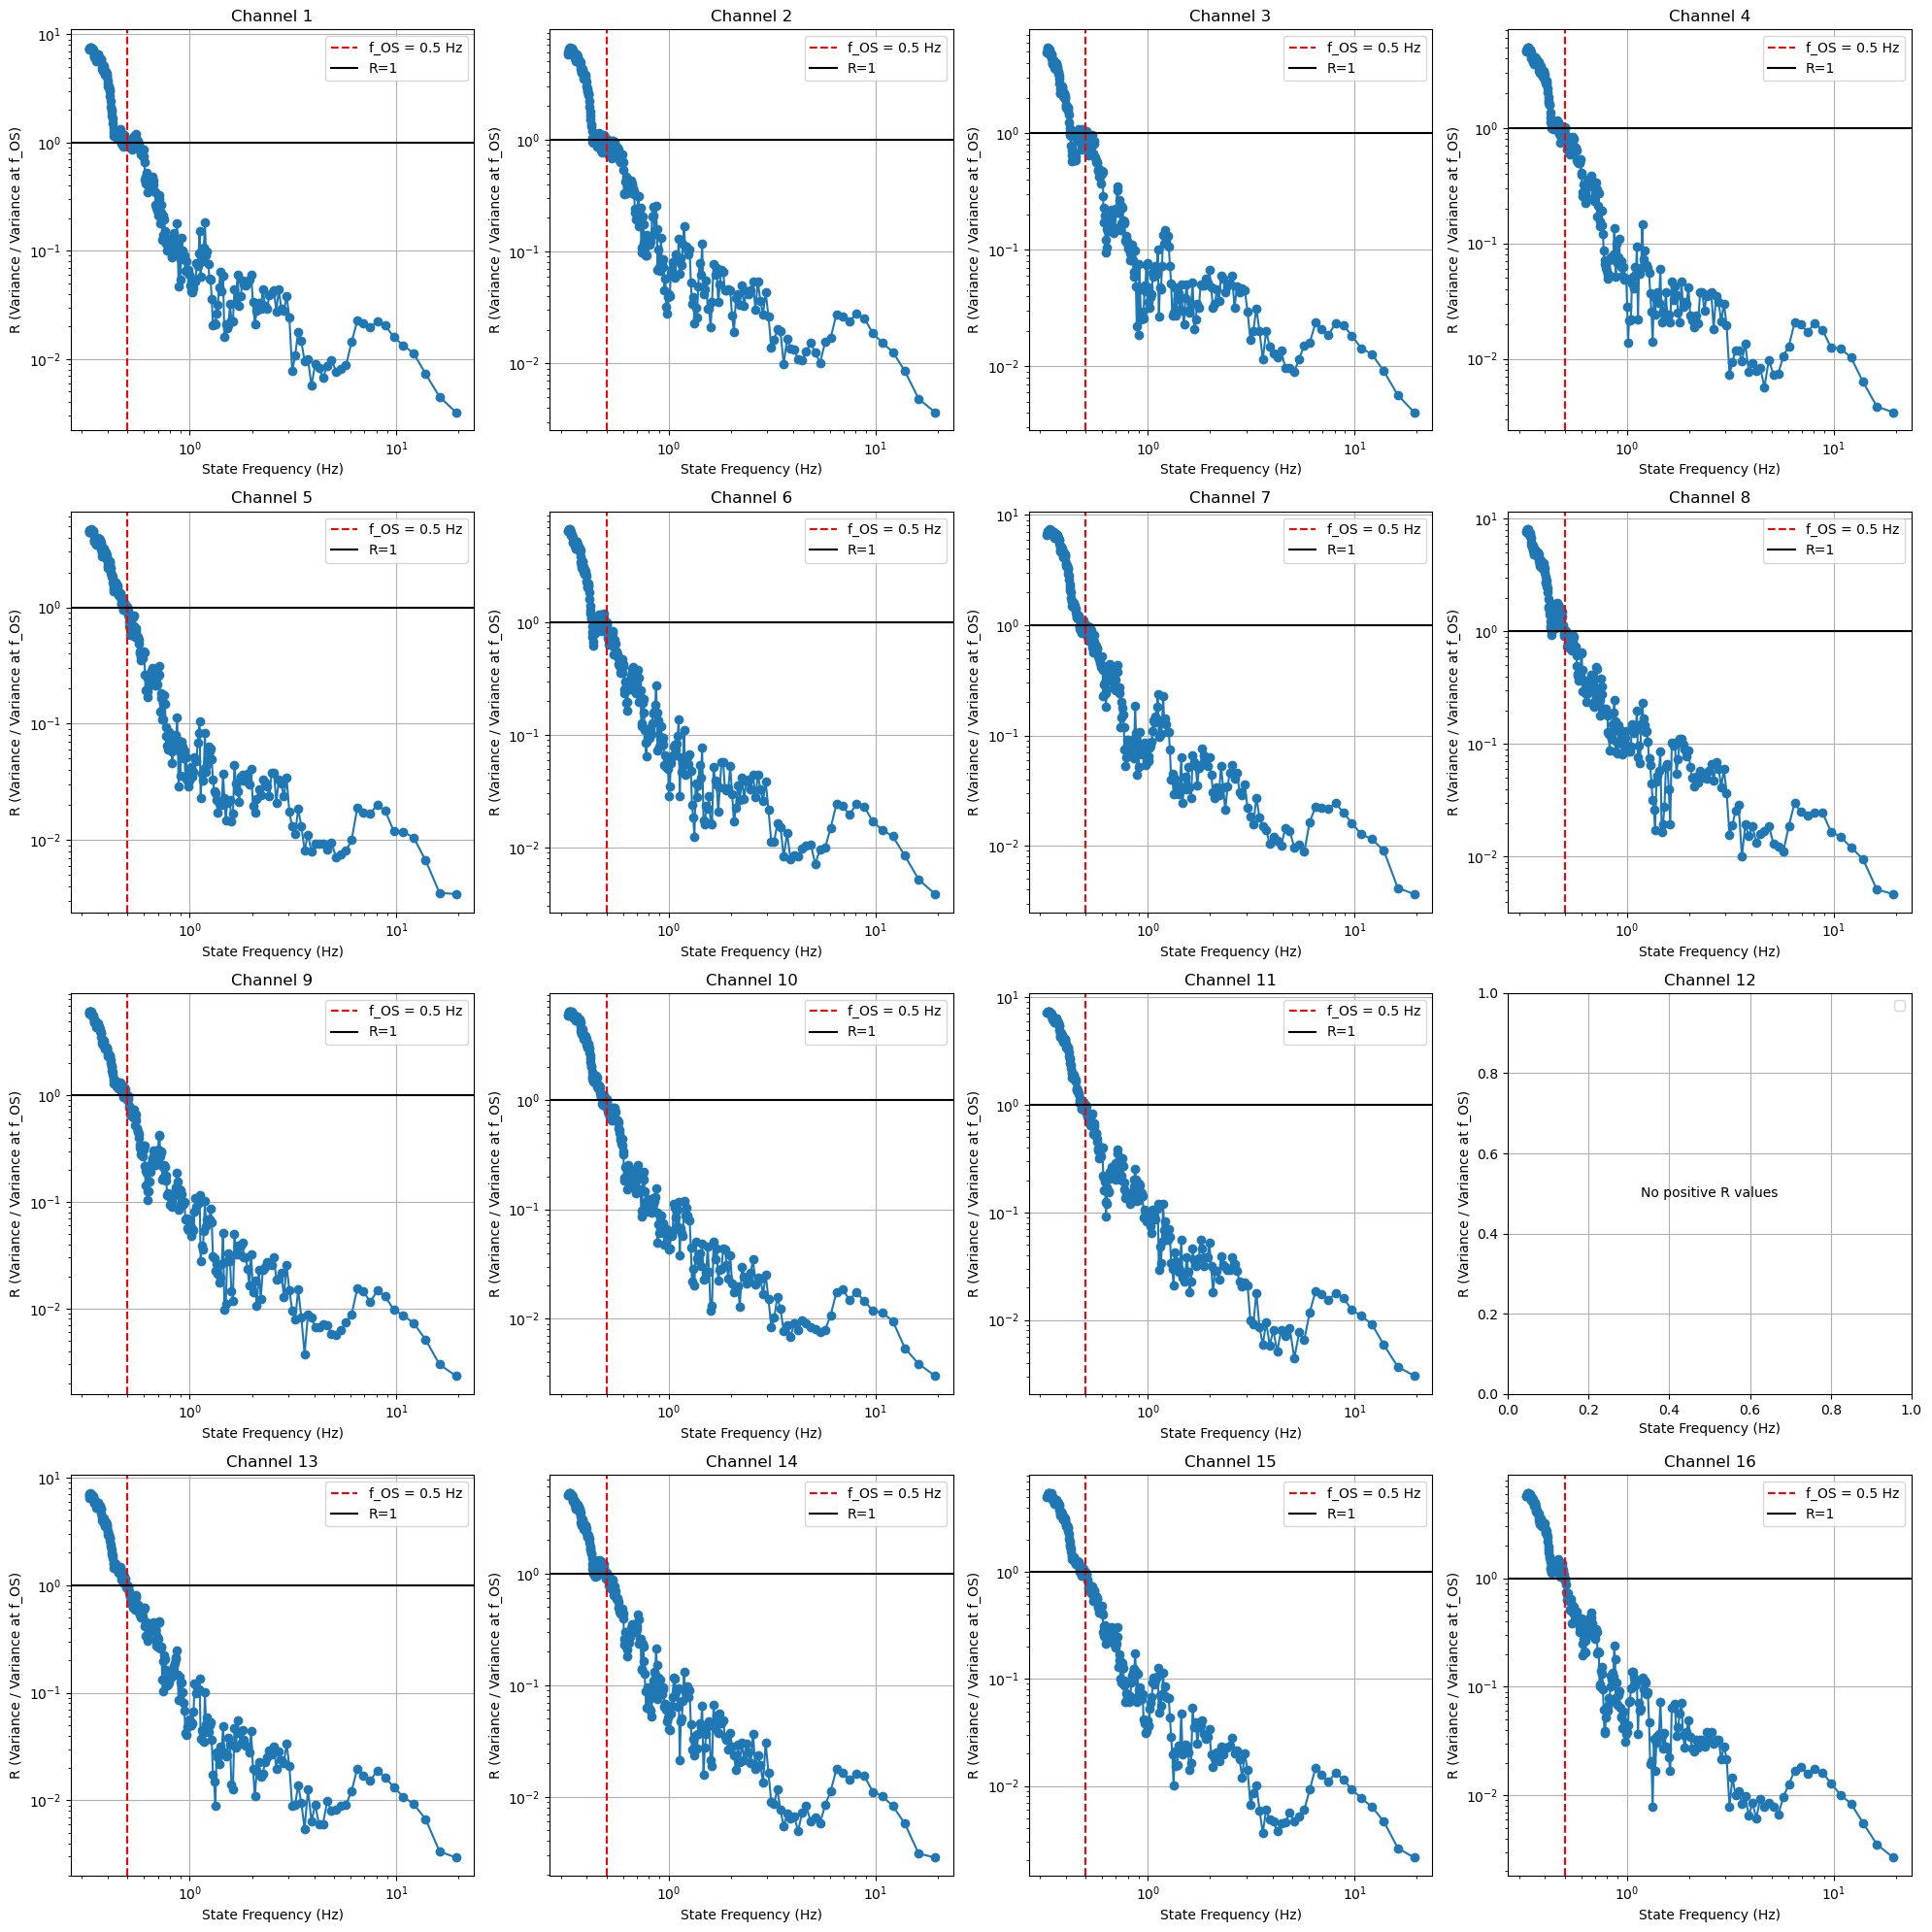

In [22]:
# Great, let's repeat the plot but using marking the F_OS point with a vertical dashed line, a black horizontal line ar R = 1, and a red fill (for the entire region) for R > 1 and a light green fill for R < 1 with text that says "no chopping improvment" 
fig, axes = plt.subplots(4, 4, figsize=(20,20))
for channel in range(result["channels"].shape[0]):
    ax = axes[channel // 4, channel % 4]
    R_values = np.array(R_factor[channel], dtype=float)
    xvals = np.array(f_state, dtype=float)

    # Log scale requires strictly positive finite values
    good = np.isfinite(R_values) & (R_values > 0) & np.isfinite(xvals) & (xvals > 0)

    if np.any(good):
        ax.plot(xvals[good], R_values[good], marker='o')
        ax.set_xscale('log')
        ax.set_yscale('log')

        # Add vertical line at f_OS
        ax.axvline(f_OS, color='red', linestyle='--', label=f'f_OS = {f_OS} Hz')

        # Add horizontal line at R=1
        ax.axhline(1, color='black', linestyle='-', label='R=1')

    else:
        ax.text(0.5, 0.5, "No positive R values", ha='center', va='center', transform=ax.transAxes)
    ax.set_title(f'Channel {channel+1}')
    ax.set_xlabel('State Frequency (Hz)')
    ax.set_ylabel('R (Variance / Variance at f_OS)')
    ax.grid(True)
    ax.legend()
plt.tight_layout()
plt.show()


So, anything to the right of this line indicates an improvement from chopping. 

We use the sky_emission python file to compute a fudicial rate for the sky given. 

In [23]:
sky_rate = 2.425e8 #ph/s/m^2/arcsec^2
tel_rate = 1.945e-5 #ph/s/m^2/arcsec^2

In [24]:
# Efficiency values
E_primary_mirror = 0.95
E_secondary_mirror = 0.98
E_dichroic = 0.94
E_ZnSe = 0.95
E_M1 = 0.95
E_M2 = 0.96 
E_Nband = 0.5 
E_BaF2 = 0.7 
E_cold_stop = 0.9
E_M3 = 0.96 
E_M4 = 0.96 
QE = 0.4

In [25]:
eta_tel = (E_secondary_mirror * E_dichroic * E_ZnSe * E_M1 * E_M2 * E_BaF2 * E_cold_stop * E_M3 * E_M4) # total telescope efficiency

In [26]:
print(f"Total telescope efficiency (eta_tel): {eta_tel:.3f}")

Total telescope efficiency (eta_tel): 0.463


In [27]:
# Total sky photons 
sky_rate_after_efficiency = sky_rate * E_primary_mirror * eta_tel * QE

In [28]:
print(f"Sky rate after efficiency (sky_rate_after_efficiency): {sky_rate_after_efficiency:.3e} ph/s/m^2/arcsec^2")

Sky rate after efficiency (sky_rate_after_efficiency): 4.270e+07 ph/s/m^2/arcsec^2


In [29]:
# Solid angle of MIRSI pixel
pixel_scale_arcsec = 0.27 # arcsec/pixel
omega_pix = pixel_scale_arcsec ** 2  # arcsec^2/pixel

# Collecting area of IRTF
D = 3.2 # Meters 
A_tel = np.pi * (D / 2) ** 2  # m^2

# Total sky photons per pixel per second
sky_photons_per_pixel_per_second = sky_rate_after_efficiency * A_tel * omega_pix

print(f"Sky photons per second per pixel: {sky_photons_per_pixel_per_second:.3e} ph/s") 

Sky photons per second per pixel: 2.504e+07 ph/s


## Calcuation of $\sigma^2_{corr,ref}$

First, we compute the fractional change in the sky frames (within the aperture) at the characteristic O-S frequency. 

In [30]:
# Bin the data so that the state frequency is f_OS = 0.5 Hz, which means we need to bin every 1/f_OS = 2 seconds. With a frame time of 0.0103 seconds, that means we need to bin every 2 / 0.0103 ≈ 194 frames.
bin_size = int(2 / 0.0103)  # Number of frames to bin together to achieve f_OS = 0.5 Hz
binned_channels = []
for channel in range(result["channels"].shape[0]):
    ch_data = result["channels"][channel]
    num_bins = ch_data.shape[0] // bin_size
    binned_ch = ch_data[:num_bins * bin_size].reshape(num_bins, bin_size, *ch_data.shape[1:]).mean(axis=1)
    binned_channels.append(binned_ch)
binned_channels = np.array(binned_channels)

In [31]:
np.shape(binned_channels)

(16, 6, 240, 20)

In [32]:
# for each binned channel find the average value of the pixel in the aperature and find the fractional variation of the pixel values in the aperture across all frames for that channel. Plot this fractional variation as a function of channel number to see if it correlates with the variance curves.
bad_channels = [11]
# Initialize array to store all the fractional variations for each channel
channel_var_del = np.zeros(binned_channels.shape[0])
for channel in range(binned_channels.shape[0]):
    if channel in bad_channels:
        print(f"Skipping Channel {channel+1} due to known issues.")
        continue
    # Initialize array for the stack variances for this channel should have shape (num_frames,)
    stack_variances = np.zeros(binned_channels.shape[1])
    # Loop over all frames in the channel compute the mean in the aperture and find the fractional change for every pixel 
    for i in range(binned_channels.shape[1]):
        # Create aperture
        ap = RectangularAperture((9, 120), 15, 15)
        mask = ap.to_mask(method='center')

        # Extract just the region inside the aperture
        # mask.bbox gives you the bounding box of the aperture
        cropped_frame = mask.multiply(binned_channels[channel, i])
        mean_ap = np.mean(cropped_frame[cropped_frame > 0]) # only take the mean of the pixels that are inside the aperture (non-zero values)
      
        # Now compute the fractional change for every pixel in the aperture and then compute the variance of the fractional change across all pixels in the aperture for this frame
        frac_change = (cropped_frame[cropped_frame > 0] - mean_ap) / mean_ap
        
        # Compute the variance of the fractional change across all pixels in the aperture for this frame and store it in the stack_variances array
        stack_variances[i] = np.var(frac_change)

    # Now we have the variance of the fractional change for each frame in this channel, we can compute the mean variance across all frames for this channel and store it in the channel_var_del array
    channel_var_del[channel] = np.mean(stack_variances)


Skipping Channel 12 due to known issues.


In [33]:
print("Fractional variation of pixel values in the aperture for each channel:")
for channel in range(result['channels'].shape[0]):
    if channel not in bad_channels:
        print(f"Channel {channel+1}: {channel_var_del[channel]}")

Fractional variation of pixel values in the aperture for each channel:
Channel 1: 0.0053485935982241625
Channel 2: 0.004568137128582315
Channel 3: 0.005832180737796015
Channel 4: 0.006618922096071719
Channel 5: 0.02567194371561576
Channel 6: 0.010797421084068672
Channel 7: 0.006619665366505584
Channel 8: 0.007698896328584413
Channel 9: 0.01197264881862177
Channel 10: 0.010857588843200797
Channel 11: 0.013124797714891908
Channel 13: 0.010267967699718026
Channel 14: 0.013615949562424309
Channel 15: 0.013311592325297375
Channel 16: 0.012190377223786188


Since we know the sky rate in electrons per 

var_corr_ref = ()

In [34]:
var_corr_ref = (sky_photons_per_pixel_per_second / f_OS)**2 * channel_var_del

In [63]:
print("correlated reference variance for each channel:")
print(var_corr_ref)

correlated reference variance for each channel:
[1.34102162e+13 1.14534233e+13 1.46226860e+13 1.65952366e+13
 6.43657645e+13 2.70717430e+13 1.65971002e+13 1.93029929e+13
 3.00183228e+13 2.72225981e+13 3.29070384e+13 0.00000000e+00
 2.57442755e+13 3.41384748e+13 3.33753777e+13 3.05642205e+13]


## Signal for the Asteriod 

## Compute $\sigma^2_{corr}(f_c)$

Text(0, 0.5, 'Expected Variance of Correlated Reference')

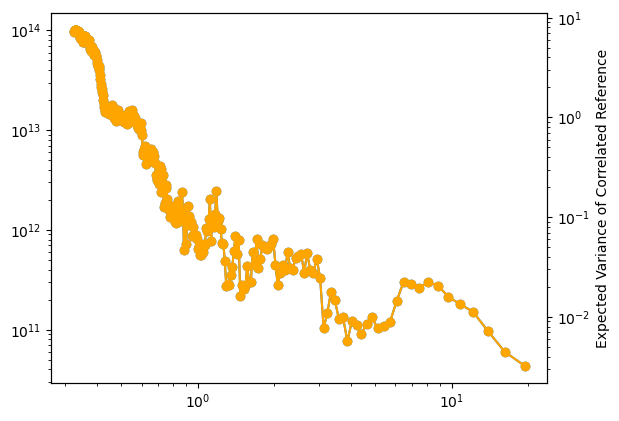

In [40]:
# Use channel 1 as an example 
expected_var_corr_ref = var_corr_ref[0] * R_factor[0, :]
plt.plot(f_state, expected_var_corr_ref, marker='o', label=f'Channel 1')
plt.yscale('log')
# Use other y axiis to plot the actual R values on the same plot
plt.twinx()
plt.plot(f_state, R_factor[0, :], marker='o', color='orange', label='R values')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('State Frequency (Hz)')
plt.ylabel('Expected Variance of Correlated Reference')

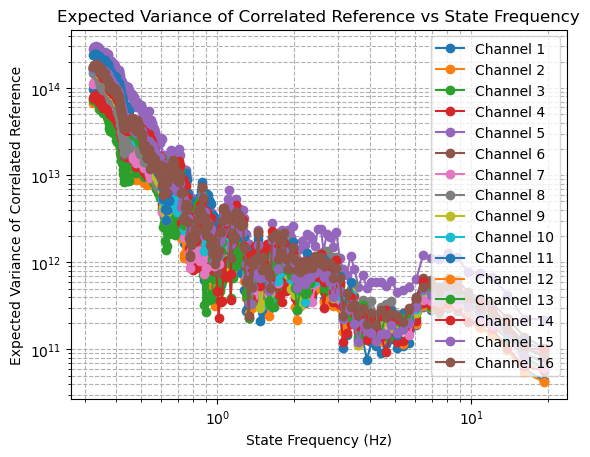

In [ ]:
# Mulitply the the correlated reference variance by the R(f_c) values to get the expected variance of the correlated reference at each state frequency for each channel

# Initialize array to store the expected variance of the correlated reference for each channel and state frequency
expected_var_corr_ref_all = np.zeros_like(R_factor)

for channel in range(result["channels"].shape[0]):
    expected_var_corr_ref = var_corr_ref[channel] * R_factor[channel, :]
    expected_var_corr_ref_all[channel, :] = expected_var_corr_ref
    plt.plot(f_state, expected_var_corr_ref, marker='o', label=f'Channel {channel+1}')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('State Frequency (Hz)')
plt.ylabel('Expected Variance of Correlated Reference')
plt.title('Expected Variance of Correlated Reference vs State Frequency')
plt.legend()
plt.grid(True, which="both", ls="--")

# Injection and Recovery

Using values from Harris 1998 (the NEATM Model paper), we can establish a fidical value for the asteroid. The nice thing about using literature values is that they are geomery, and object constrained. That is to say, thiis the known flux for that object at the specific distance it was observed. 

From looking at the plots, it seems like the flux throughout N-band (8.5 - 13 microns is something like 9 x 10^-13 W /m^2/micron). We adopt this as the a uniform "in-band value"

In [ ]:
# Make a fudicial plot which 

## Compute the sky shot noise

Given the sky rate, the shot noise is just $\sqrt{N}$

In [42]:
N_pix = ap.area  # Number of pixels in the aperture

In [43]:
print(N_pix)

225.0


R values for Channel 1: [3.22767912e-03 4.47739404e-03 7.27522850e-03 1.12786525e-02
 1.34167026e-02 1.59704081e-02 2.05945837e-02 2.23246138e-02
 1.95359614e-02 2.13087817e-02 2.26061399e-02 1.43184337e-02
 8.80040731e-03 8.07925515e-03 7.67431611e-03 9.86377490e-03
 8.55596642e-03 6.74434372e-03 8.21146248e-03 9.00531490e-03
 5.68138851e-03 9.96287223e-03 9.52423006e-03 1.46487447e-02
 1.79121811e-02 1.08217208e-02 7.72173653e-03 2.44512635e-02
 3.84035711e-02 2.77374836e-02 2.93799676e-02 4.38178883e-02
 2.77095234e-02 4.27940265e-02 4.07361872e-02 3.91615601e-02
 2.94434060e-02 3.11891144e-02 4.43382644e-02 2.92342354e-02
 3.29942268e-02 2.77744063e-02 2.09251363e-02 3.33943136e-02
 6.00141645e-02 5.40782024e-02 5.13458325e-02 4.79519087e-02
 4.86945888e-02 5.28634766e-02 3.83356030e-02 3.11273081e-02
 6.04077871e-02 3.32416825e-02 4.44023459e-02 2.25397668e-02
 2.25540545e-02 3.22235431e-02 2.05343439e-02 1.91845411e-02
 2.08505584e-02 1.60210376e-02 5.84441767e-02 4.25531124e-02


/tmp/ipykernel_2032838/1919445170.py:17: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale('log')


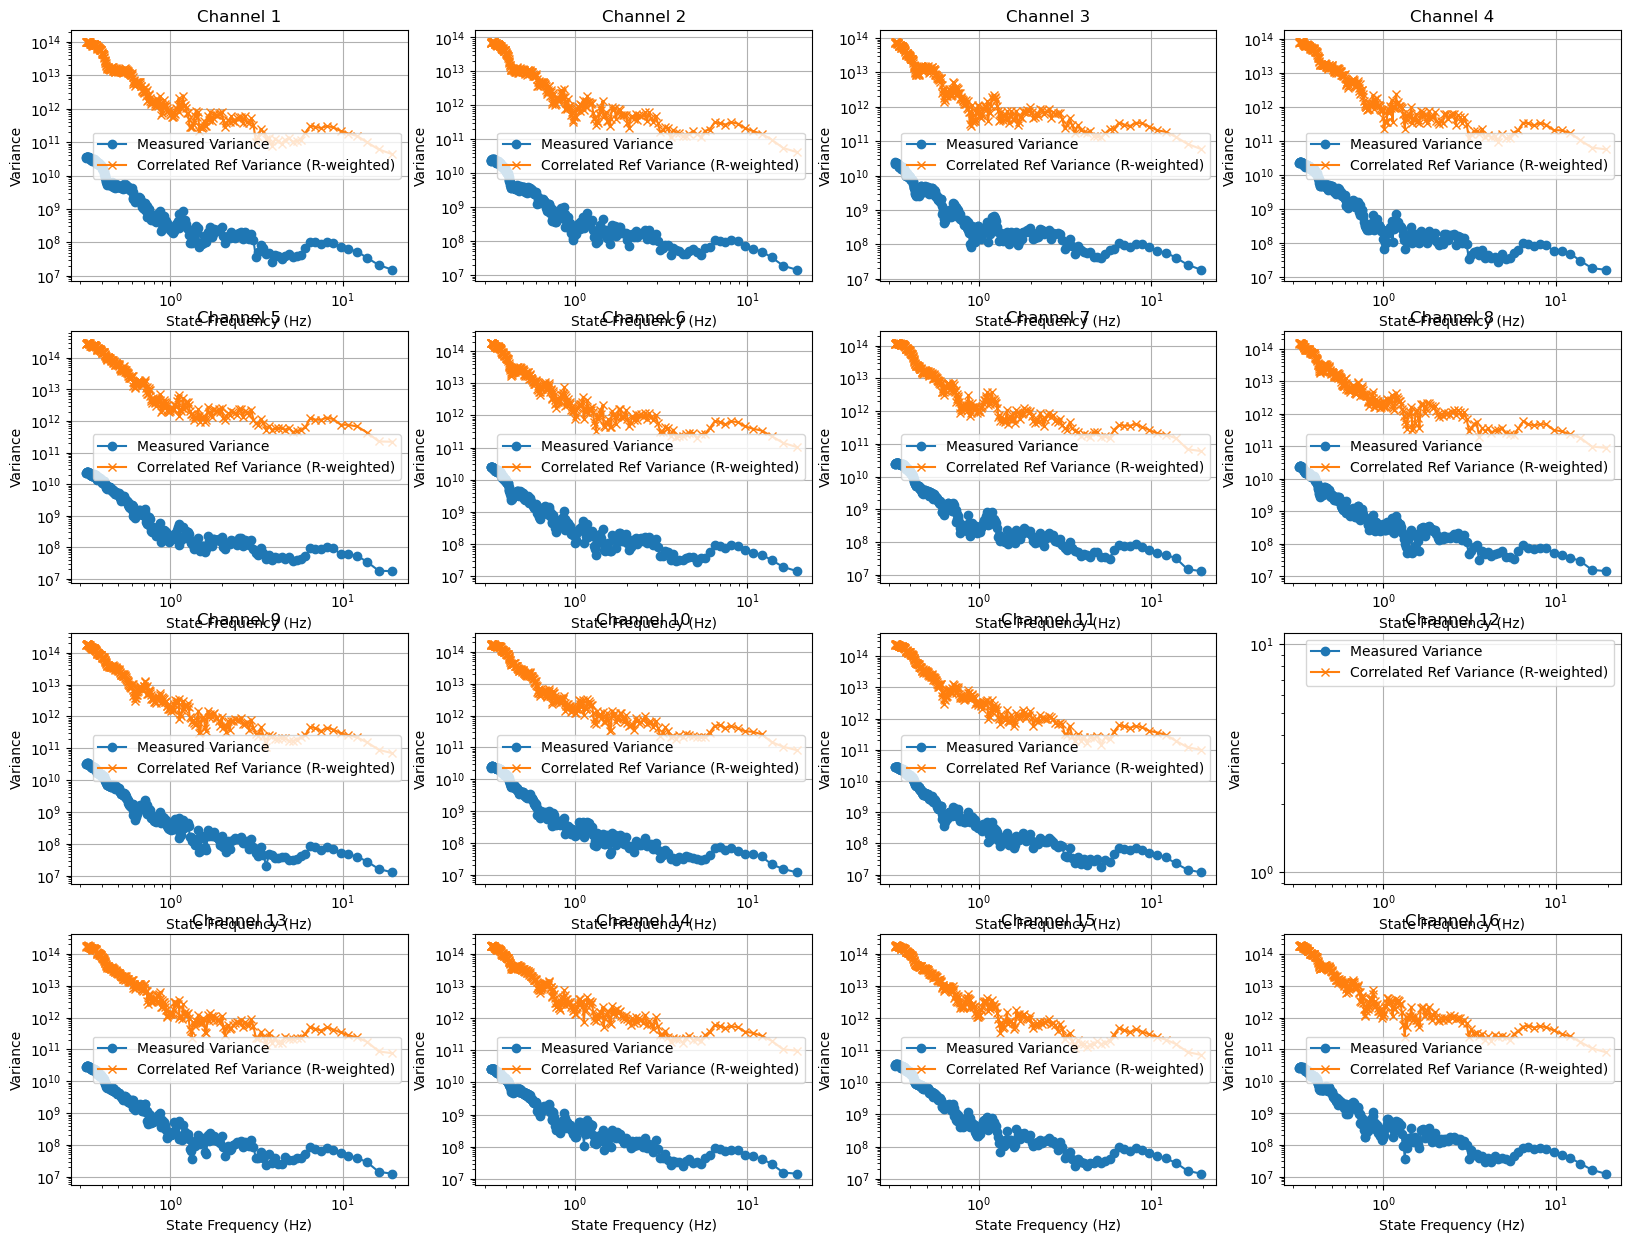

From the 

In [ ]:
F_ast = 

clearly channel 12 has something wrong with it. maybe what we can do is take the median of each and normalize the values to the "empirical sky rate".   

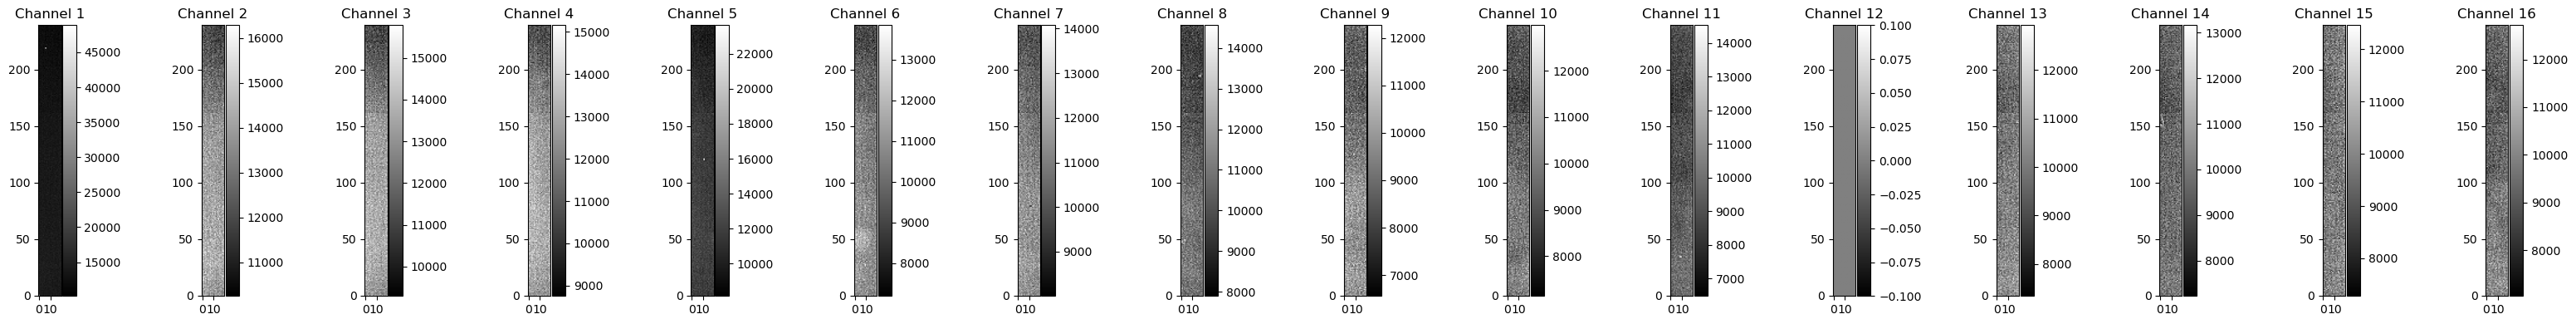

In [ ]:
num_channels = 16
channel_width = 20

zenith_sky_1_data_norm = zenith_sky_1_data.astype(float).copy()

fig, axes = plt.subplots(1, num_channels, figsize=(32, 4))

for i in range(num_channels):
    c0 = i * channel_width
    c1 = (i + 1) * channel_width
    
    # first frame of normalized data for this channel
    ch0 = zenith_sky_1_data_norm[0, :, c0:c1]
    
    im = axes[i].imshow(ch0, cmap='gray', origin='lower')
    axes[i].set_title(f"Channel {i+1}")
    plt.colorbar(im, ax=axes[i], pad=0.01)

plt.tight_layout()
plt.show()

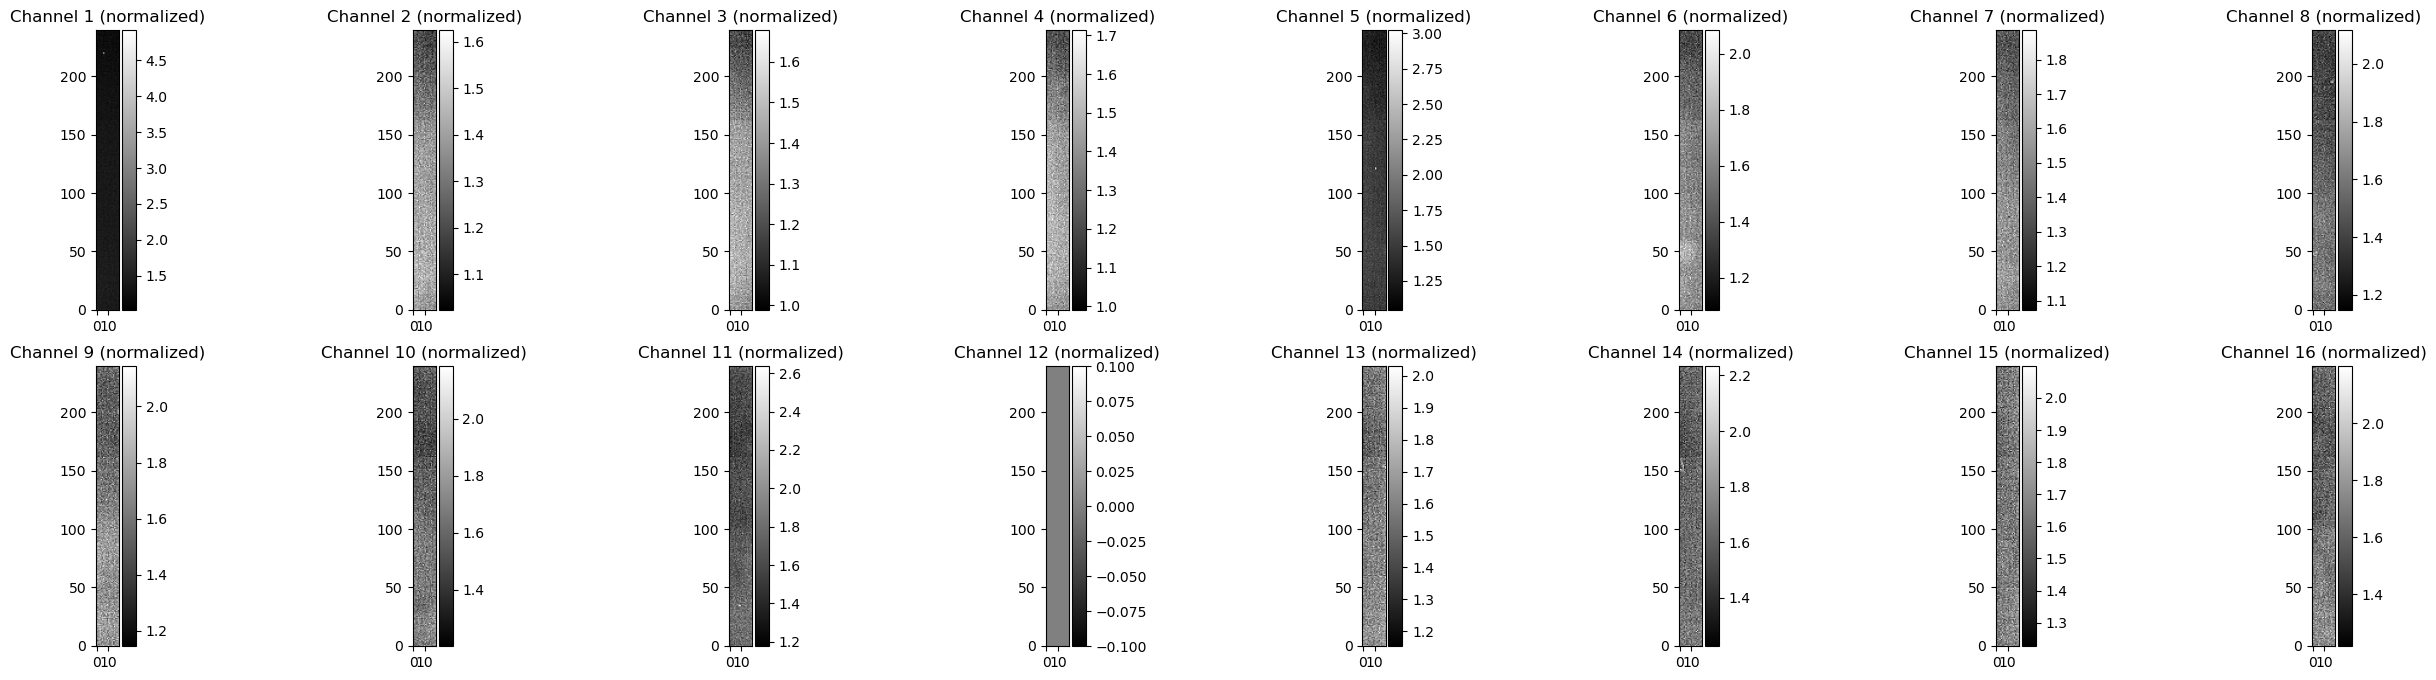

In [ ]:
# normalize each channel by the median of itself 
fig, axes = plt.subplots(2, num_channels//2, figsize=(32, 8))
for i in range(num_channels):
    c0 = i * channel_width
    c1 = (i + 1) * channel_width
    channel = zenith_sky_1_data_norm[:, :, c0:c1]
    med = np.nanmedian(channel)
    if med != 0:
        zenith_sky_1_data_norm[:, :, c0:c1] = channel / med

    im = axes[i//(num_channels//2), i%(num_channels//2)].imshow(zenith_sky_1_data_norm[0, :, c0:c1], cmap='gray', origin='lower')
    axes[i//(num_channels//2), i%(num_channels//2)].set_title(f"Channel {i+1} (normalized)")
    plt.colorbar(im, ax=axes[i//(num_channels//2), i%(num_channels//2)], pad=0.01)


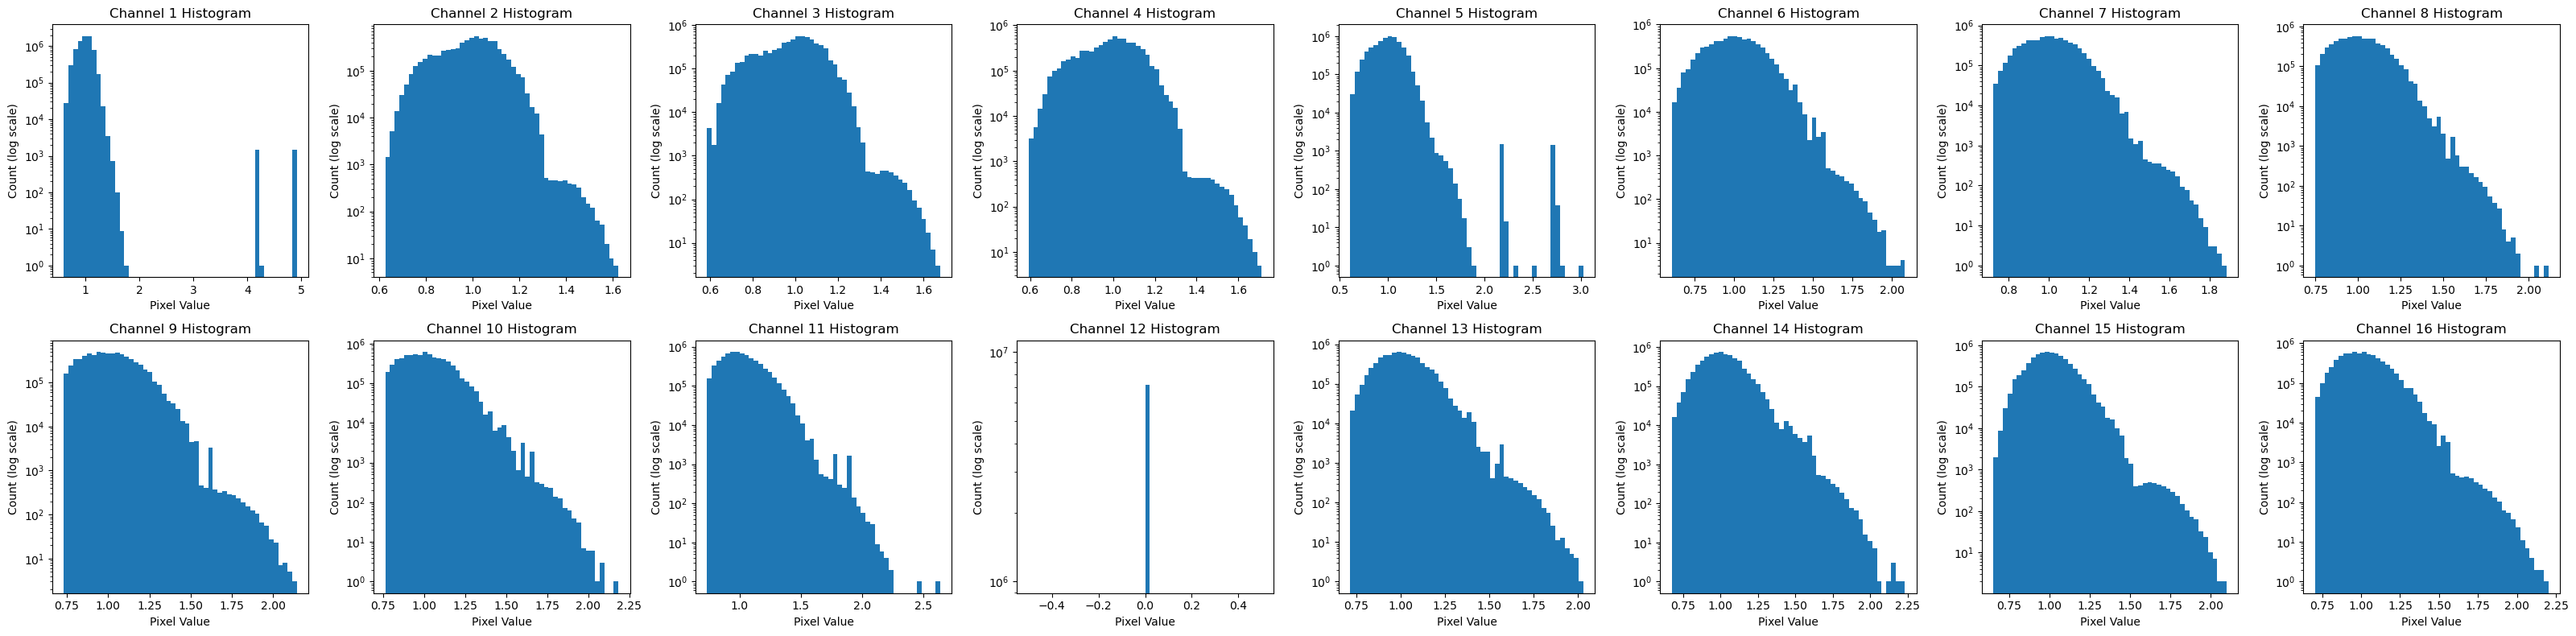

In [ ]:
# histograms for each channel
fig, axes = plt.subplots(2, num_channels//2, figsize=(32, 8))
for i in range(num_channels):
    c0 = i * channel_width
    c1 = (i + 1) * channel_width
    channel = zenith_sky_1_data_norm[:, :, c0:c1]
    
    # Ignoring NaNs for histogram
    channel = channel[~np.isnan(channel)]
    axes[i//(num_channels//2), i%(num_channels//2)].hist(channel.flatten(), bins=50, log=True)
    axes[i//(num_channels//2), i%(num_channels//2)].set_title(f"Channel {i+1} Histogram")
    axes[i//(num_channels//2), i%(num_channels//2)].set_xlabel("Pixel Value")
    axes[i//(num_channels//2), i%(num_channels//2)].set_ylabel("Count (log scale)")

plt.tight_layout()
plt.show()

Now, multiply the pixel value by the expected number of sky photons

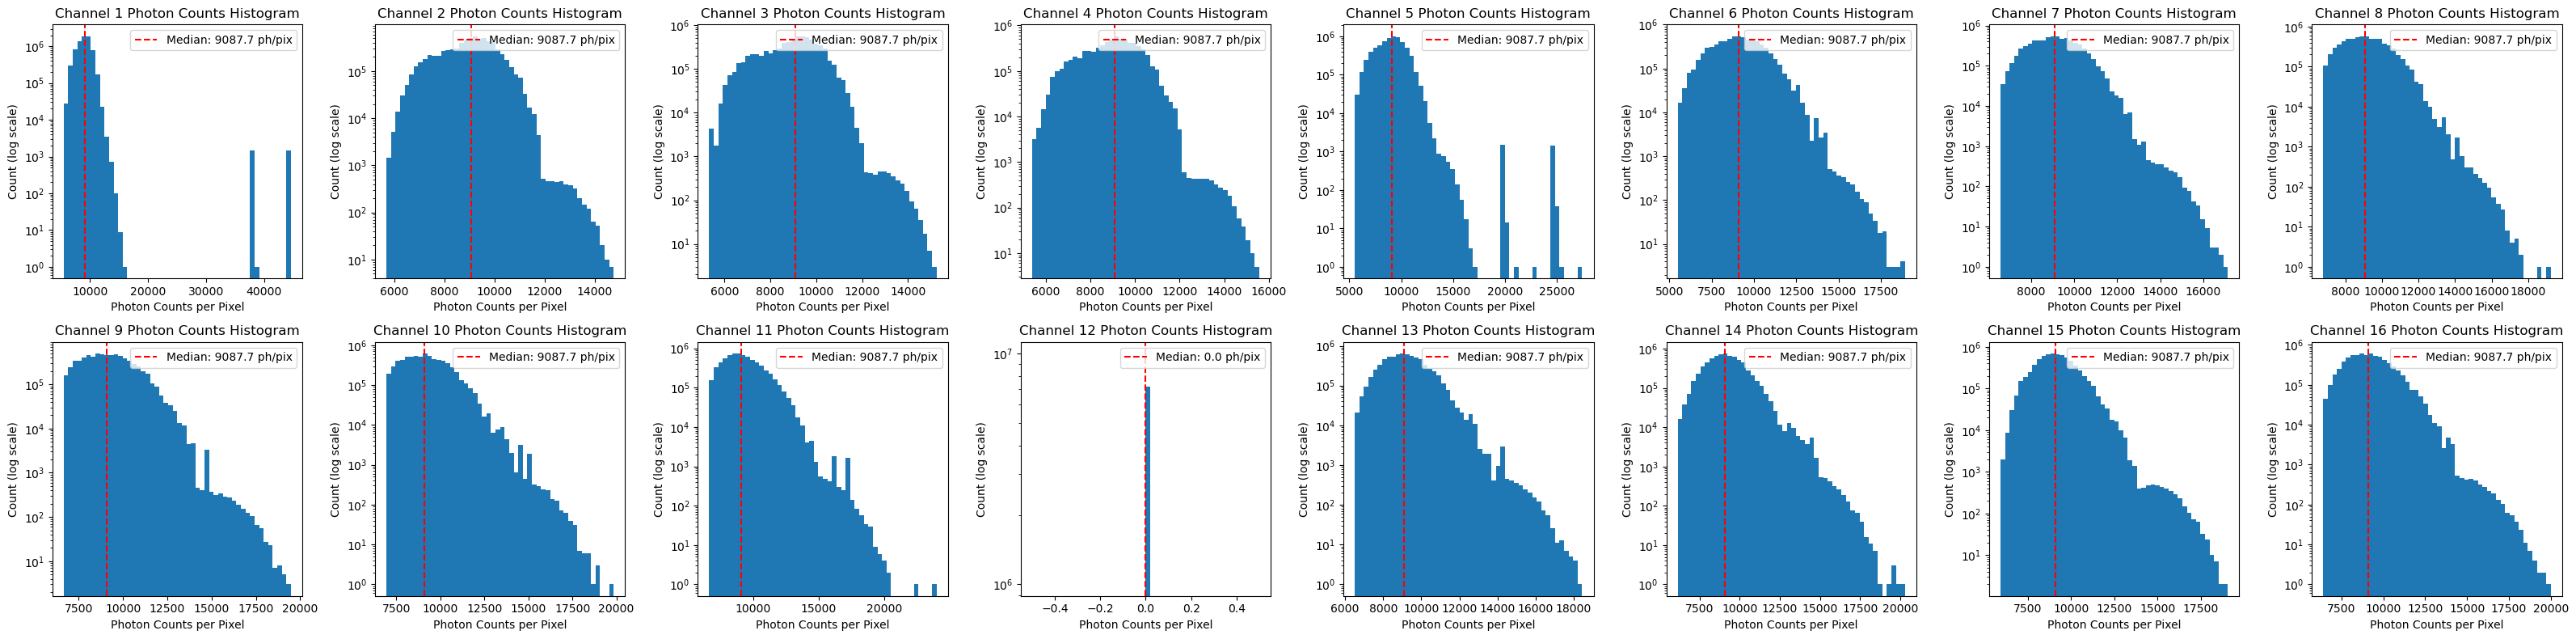

In [ ]:
# Multiply each pixel value by the sky photon rate per pixel
sky_rate = 9087.657082019272 # ph/pix

# muliply zenith_sky_1_data_norm by the sky rate to get an estimate of the photon counts per pixel if not nan
zenith_sky_1_data_photons = np.where(np.isnan(zenith_sky_1_data_norm), np.nan, zenith_sky_1_data_norm * sky_rate)

# Generate histograms of the photon counts for each channel
fig, axes = plt.subplots(2, num_channels//2, figsize=(32, 8))
for i in range(num_channels):
    c0 = i * channel_width
    c1 = (i + 1) * channel_width
    channel = zenith_sky_1_data_photons[:, :, c0:c1]
    
    # Ignoring NaNs for histogram
    channel = channel[~np.isnan(channel)]
    axes[i//(num_channels//2), i%(num_channels//2)].hist(channel.flatten(), bins=50, log=True)
    axes[i//(num_channels//2), i%(num_channels//2)].set_title(f"Channel {i+1} Photon Counts Histogram")
    axes[i//(num_channels//2), i%(num_channels//2)].set_xlabel("Photon Counts per Pixel")
    axes[i//(num_channels//2), i%(num_channels//2)].set_ylabel("Count (log scale)") 

    # axvline for the median photon count in this channel
    median_photon_count = np.median(channel)
    axes[i//(num_channels//2), i%(num_channels//2)].axvline(median_photon_count, color='red', linestyle='dashed', label=f'Median: {median_photon_count:.1f} ph/pix')
    axes[i//(num_channels//2), i%(num_channels//2)].legend()
plt.tight_layout()
plt.show()

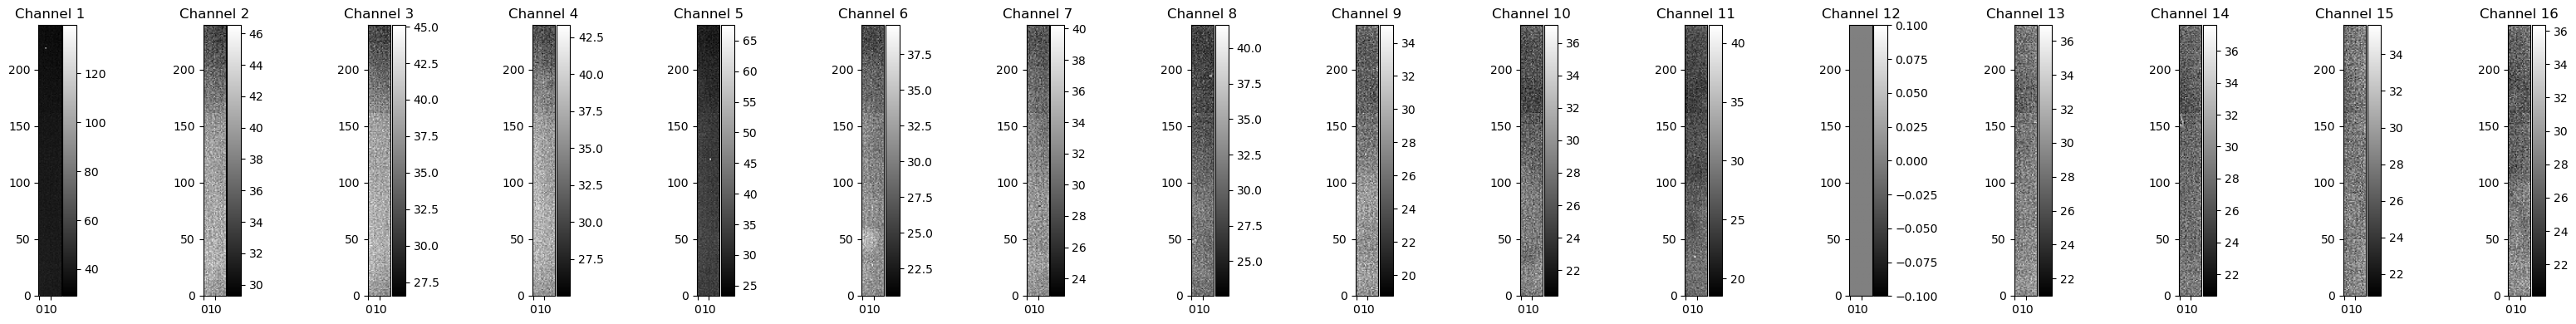

In [ ]:
# Now that we have a gain measurment, we don't need to do the nomralization by the median for each channel, we can just convert the original data to photon counts directly and then analyze the timeseries. Let's do that and then compute the variance of the timeseries for each channel to see how it compares to our gain measurement.
Gain = 350 # e-/photon
#make a copy of the original data and convert to photon counts using the gain
zenith_sky_1_data_photons = zenith_sky_1_data.astype(float).copy() / Gain

#Plot the channels 
fig, axes = plt.subplots(1, num_channels, figsize=(32, 4))

for i in range(num_channels):
    c0 = i * channel_width
    c1 = (i + 1) * channel_width
    
    # first frame of normalized data for this channel
    ch0 = zenith_sky_1_data_photons[0, :, c0:c1]
    
    im = axes[i].imshow(ch0, cmap='gray', origin='lower')
    axes[i].set_title(f"Channel {i+1}")
    plt.colorbar(im, ax=axes[i], pad=0.01)

plt.tight_layout()
plt.show()

IndexError: index 4 is out of bounds for axis 1 with size 4

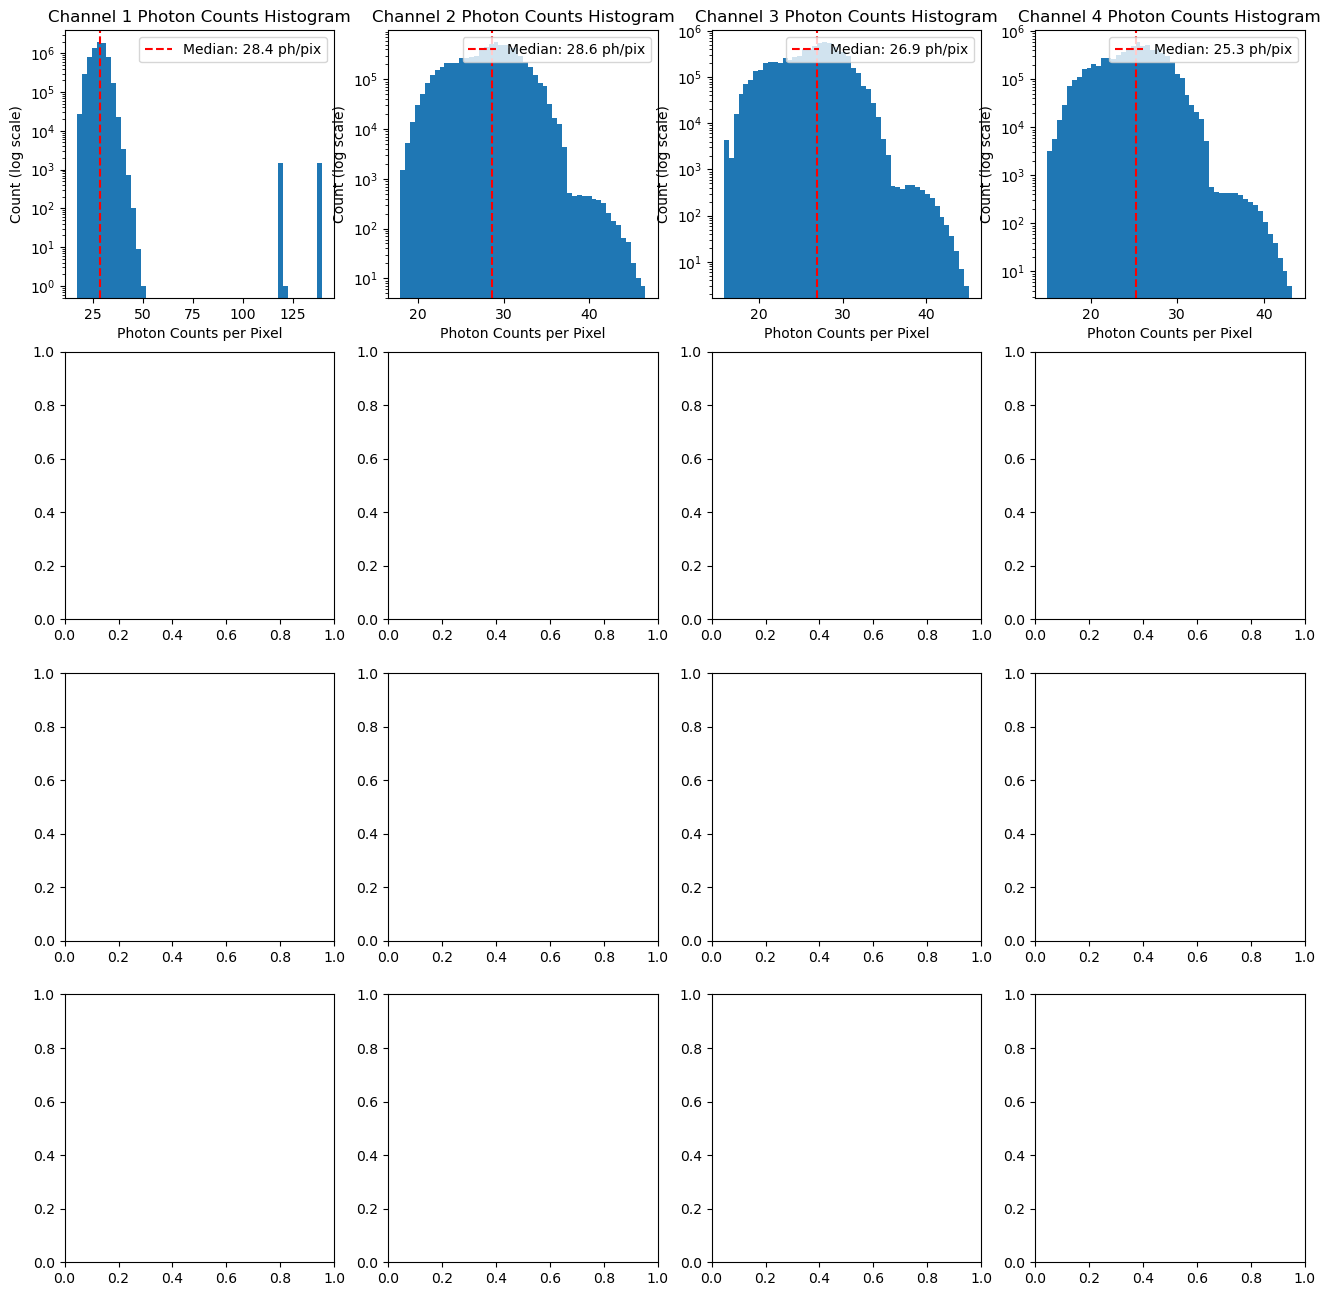

In [ ]:
#Plot the histograms of the photon counts for each channel (in a a 4x4 grid)
fig, axes = plt.subplots(4, num_channels//4, figsize=(16,16))
for i in range(num_channels):
    c0 = i * channel_width
    c1 = (i + 1) * channel_width
    channel = zenith_sky_1_data_photons[:, :, c0:c1]
    
    # Ignoring NaNs for histogram
    channel = channel[~np.isnan(channel)]
    axes[i//(num_channels//2), i%(num_channels//2)].hist(channel.flatten(), bins=50, log=True)
    axes[i//(num_channels//2), i%(num_channels//2)].set_title(f"Channel {i+1} Photon Counts Histogram")
    axes[i//(num_channels//2), i%(num_channels//2)].set_xlabel("Photon Counts per Pixel")
    axes[i//(num_channels//2), i%(num_channels//2)].set_ylabel("Count (log scale)") 

    # axvline for the median photon count in this channel
    median_photon_count = np.median(channel)
    axes[i//(num_channels//2), i%(num_channels//2)].axvline(median_photon_count, color='red', linestyle='dashed', label=f'Median: {median_photon_count:.1f} ph/pix')
    axes[i//(num_channels//2), i%(num_channels//2)].legend()
plt.tight_layout()
plt.show()

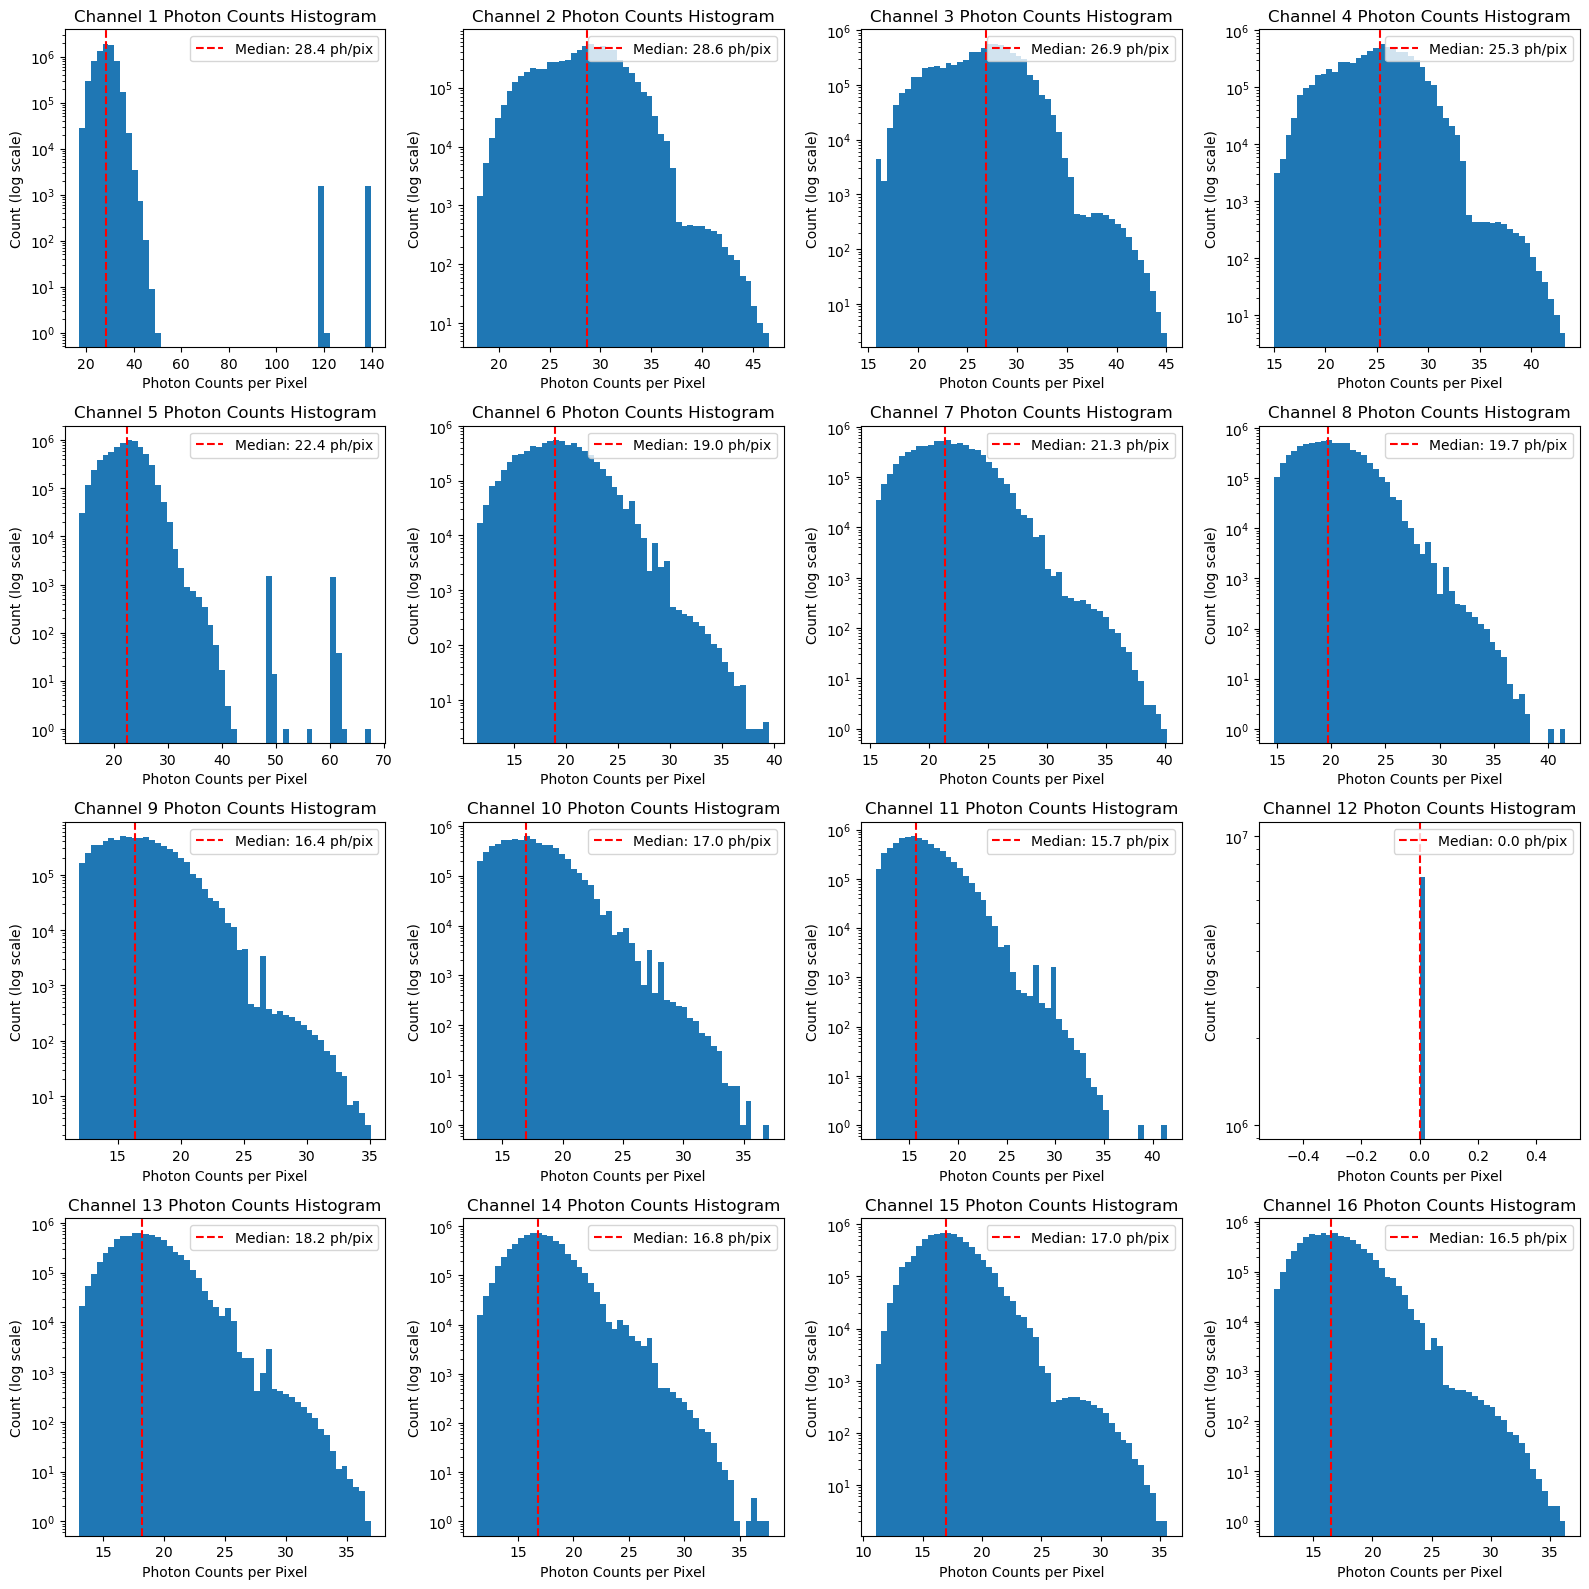

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.ravel()

for i in range(num_channels):
    c0 = i * channel_width
    c1 = (i + 1) * channel_width
    channel = zenith_sky_1_data_photons[:, :, c0:c1]

    channel = channel[~np.isnan(channel)]

    axes[i].hist(channel.flatten(), bins=50, log=True)
    axes[i].set_title(f"Channel {i+1} Photon Counts Histogram")
    axes[i].set_xlabel("Photon Counts per Pixel")
    axes[i].set_ylabel("Count (log scale)")

    median_photon_count = np.median(channel)
    axes[i].axvline(
        median_photon_count,
        color='red',
        linestyle='dashed',
        label=f"Median: {median_photon_count:.1f} ph/pix"
    )
    axes[i].legend()

plt.tight_layout()
plt.show()

## Channel 2 Injection

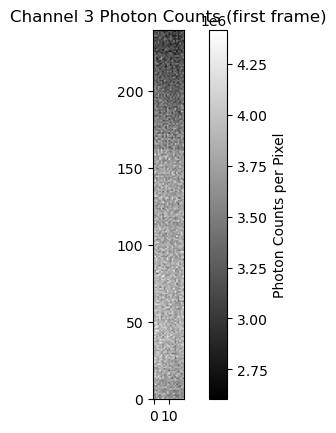

In [ ]:
channel = 2
c0 = channel * channel_width
c1 = (channel + 1) * channel_width
ch2 = zenith_sky_1_data_photons[:, :, c0:c1]
plt.imshow(ch2[0], cmap='gray', origin='lower')
plt.title(f"Channel {channel+1} Photon Counts (first frame)")
plt.colorbar(label="Photon Counts per Pixel")
plt.show()

In [ ]:
# For IRTF, the pixel scale is 0.27" and the diffraction limited psf has a FWHM of 0.84" 
# Determine the FWHM in pixels
pixel_scale = 0.27 # arcsec/pixel
FWHM_arcsec = 0.84 # arcsec
FWHM_pixels = FWHM_arcsec / pixel_scale
print(f"FWHM in pixels: {FWHM_pixels:.2f} pixels")

FWHM in pixels: 3.11 pixels


In [ ]:
# inject a fake point source into ch2 
def gaussian_2d(x, y, x0, y0, sigma_x, sigma_y, amplitude):
    return amplitude * np.exp(-(((x - x0) ** 2) / (2 * sigma_x ** 2) + ((y - y0) ** 2) / (2 * sigma_y ** 2)))

def sigma(FWHM_pixels):
    # assume a FWHM of 3 pixels for the point source
    sigma = FWHM_pixels / (2 * np.sqrt(2 * np.log(2)))
    return sigma

In [ ]:
def inject_point_source(image, x0, y0, FWHM_pixels, amplitude):
    sigma_x = sigma(FWHM_pixels)
    sigma_y = sigma(FWHM_pixels)
    
    # Create a grid of x and y coordinates
    y, x = np.indices(image.shape)
    
    # Generate the 2D Gaussian PSF
    psf = gaussian_2d(x, y, x0, y0, sigma_x, sigma_y, amplitude)

    # Add shot noise to the PSF (assuming Poisson statistics)
    psf_noisy = np.random.poisson(psf)
    
    # Inject the point source into the image
    injected_image = image + psf_noisy
    
    return injected_image

NameError: name 'ax' is not defined

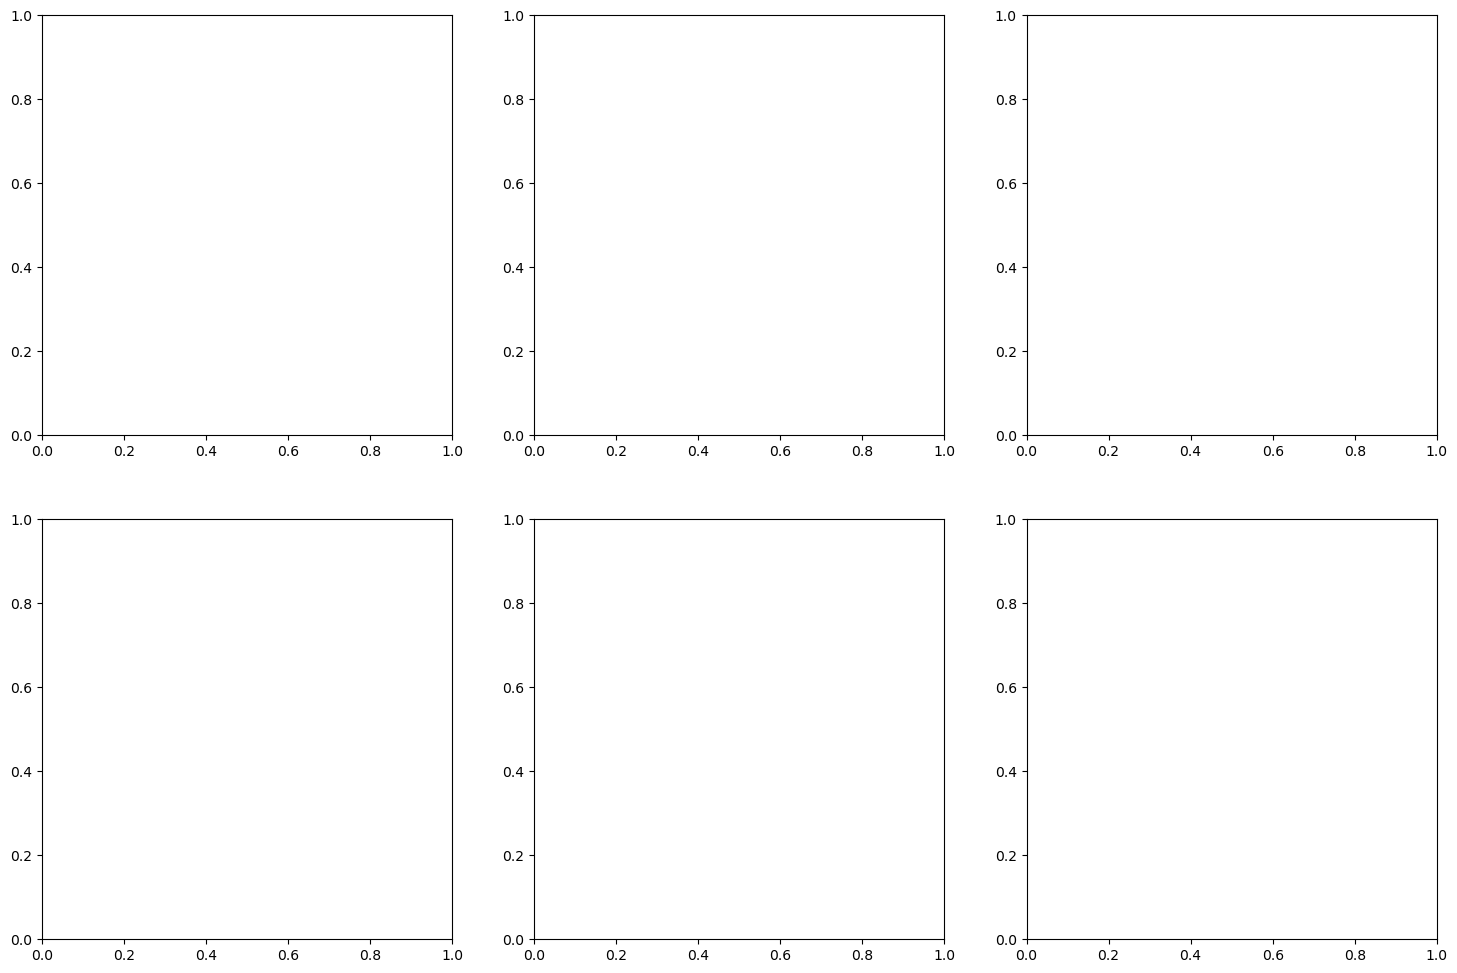

In [ ]:
# Inject point source at (10, 100)
x0, y0 = 10, 100

# Amplitudes 
frac_amplitudes = [0.001, 0.1, 0.5, 1., 50, 100]
# For each amplitude, inject the point source and plot the result
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for i, amp in enumerate(frac_amplitudes):
    injected_image = inject_point_source(ch2[0], x0, y0, FWHM_pixels, amp * sky_rate)

    # perform aperture photometry on the injected image to see if we can recover the injected flux
# perform aperture photometry on the injected image to see if we can recover the injected flux
    positions = [(x0, y0)]
    aperture = CircularAperture(positions, r=FWHM_pixels)
    annulus_aperture = CircularAnnulus(positions, r_in=FWHM_pixels*1.5, r_out=FWHM_pixels*2.5)
    aperture_masks = aperture.to_mask(method='center')
    annulus_masks = annulus_aperture.to_mask(method='center')
    aperture_data = aperture_masks[0].multiply(injected_image)
    annulus_data = annulus_masks[0].multiply(injected_image)
    aperture_sum = np.nansum(aperture_data)
    annulus_sum = np.nansum(annulus_data)
    annulus_area = annulus_aperture.area  # This is already just the annulus area
    background_per_pixel = annulus_sum / annulus_area
    signal = aperture_sum - (background_per_pixel * aperture.area)
    noise = np.sqrt(aperture_sum + (background_per_pixel * aperture.area))
    snr = signal / noise if noise > 0 else 0

    # Draw the annulus and aperture on the image
    aperture.plot(ax, color='red', lw=0.5)
    annulus_aperture.plot(ax, color='blue', lw=0.5)


    ax = axes[i//3, i%3]
    im = ax.imshow(injected_image, cmap='gray', origin='lower')
    ax.set_title(f"Injected Point Source (Amplitude: {amp} * sky_rate )\nSNR: {snr:.2f}")
    plt.colorbar(im, ax=ax, pad=0.01)

In [ ]:
# Draw apertures for photometry and compute the signal-to-noise ratio for each injected source


Text(0.5, 1.0, 'Injected Point Source (Amplitude: 908765.7 ph/pix)\nSNR: 2859.69')